In [1]:
from pathlib import Path
import pandas as pd

# Run directories from the previous notebook.
paper_run_dir = Path("runs/qwen35-4b-posttrained-s2/paper_protocol")
s1_dir = paper_run_dir / "s1_comparison"

comparison_path = s1_dir / "comparison_metric_means.csv"

assert comparison_path.exists(), (
    f"Missing {comparison_path}. "
    "Run this notebook from the euphoria-axis repo root."
)

comparison_curves = pd.read_csv(comparison_path)

required_columns = {
    "direction",
    "coeff",
    "positive_relief",
    "excited",
    "repeat4",
    "repeated_options",
}
missing = required_columns - set(comparison_curves.columns)
assert not missing, f"Missing columns: {sorted(missing)}"

expected_directions = {
    "S1_matched",
    "S2",
    "random_1103",
    "random_2207",
    "random_3301",
}
present_directions = set(comparison_curves["direction"])
assert expected_directions <= present_directions, (
    f"Missing directions: {sorted(expected_directions - present_directions)}"
)

comparison_curves = comparison_curves.sort_values(
    ["direction", "coeff"]
).reset_index(drop=True)

print("Loaded:", comparison_path)
print("Rows:", len(comparison_curves))
print("Directions:", sorted(comparison_curves["direction"].unique()))
print("Coefficients:", sorted(comparison_curves["coeff"].unique()))

display(
    comparison_curves[
        comparison_curves["direction"].isin(["S1_matched", "S2"])
    ].pivot(
        index="direction",
        columns="coeff",
        values=["positive_relief", "excited"],
    )
)

Loaded: runs/qwen35-4b-posttrained-s2/paper_protocol/s1_comparison/comparison_metric_means.csv
Rows: 55
Directions: ['S1_matched', 'S2', 'random_1103', 'random_2207', 'random_3301']
Coefficients: [np.float64(-3.0), np.float64(-2.0), np.float64(-1.5), np.float64(-1.0), np.float64(-0.5), np.float64(0.0), np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(3.0)]


positive_relief                                                     \
coeff                 -3.0  -2.0  -1.5  -1.0  -0.5   0.0   0.5  1.0  1.5  2.0   
direction                                                                       
S1_matched            0.08  0.58  0.92  0.96  0.84  0.66  0.24  0.0  0.0  0.0   
S2                    0.22  0.68  0.96  0.92  0.88  0.66  0.20  0.0  0.0  0.0   

            ... excited                                                    
coeff       ...    -2.0  -1.5  -1.0  -0.5   0.0   0.5  1.0  1.5  2.0  3.0  
direction   ...                                                            
S1_matched  ...    0.04  0.22  0.58  0.48  0.12  0.02  0.0  0.0  0.0  0.0  
S2          ...    0.44  0.86  0.78  0.70  0.12  0.02  0.0  0.0  0.0  0.0  

[2 rows x 22 columns]

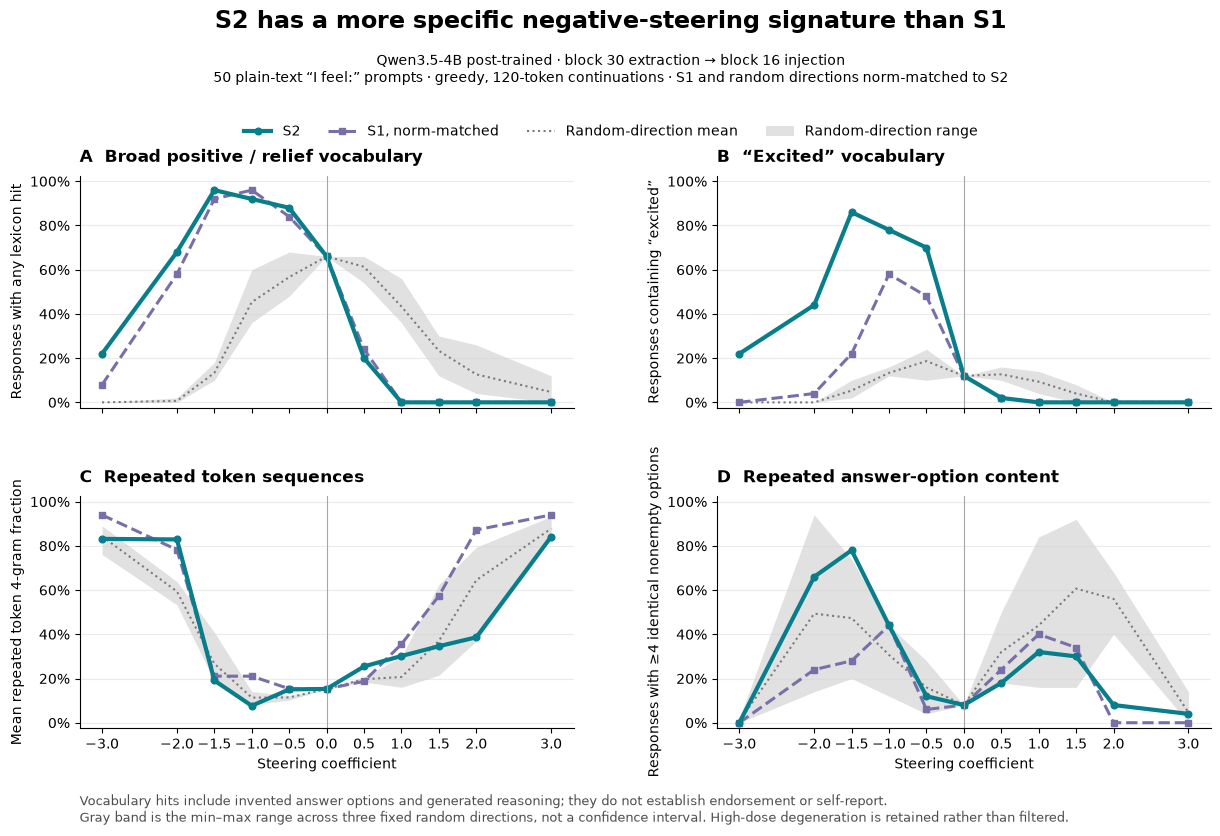


coefficient -1.5
  positive_relief    S2= 96.0%  S1= 92.0%  random= 13.3% [10.0, 18.0]
  excited            S2= 86.0%  S1= 22.0%  random=  5.3% [ 2.0, 10.0]
  repeat4            S2= 19.1%  S1= 21.1%  random= 26.7% [18.9, 40.9]
  repeated_options   S2= 78.0%  S1= 28.0%  random= 47.3% [20.0, 74.0]

coefficient -1.0
  positive_relief    S2= 92.0%  S1= 96.0%  random= 45.3% [36.0, 60.0]
  excited            S2= 78.0%  S1= 58.0%  random= 13.3% [12.0, 16.0]
  repeat4            S2=  7.7%  S1= 21.0%  random= 11.4% [ 8.2, 14.1]
  repeated_options   S2= 44.0%  S1= 44.0%  random= 30.7% [12.0, 44.0]

coefficient -0.5
  positive_relief    S2= 88.0%  S1= 84.0%  random= 56.7% [48.0, 68.0]
  excited            S2= 70.0%  S1= 48.0%  random= 18.7% [10.0, 24.0]
  repeat4            S2= 15.1%  S1= 15.4%  random= 11.4% [10.2, 12.4]
  repeated_options   S2= 12.0%  S1=  6.0%  random= 16.0% [ 4.0, 28.0]


In [2]:
# S1 / S2 specificity figure with equal-norm random-direction controls.
#
# The random band is the min–max range across the three fixed random
# directions, not a confidence interval.

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd

random_names = sorted(
    name for name in comparison_curves["direction"].unique()
    if name.startswith("random_")
)
assert random_names == ["random_1103", "random_2207", "random_3301"]

compare_names = ["S1_matched", "S2"]
metrics = [
    ("positive_relief",
     "A  Broad positive / relief vocabulary",
     "Responses with any lexicon hit"),
    ("excited",
     'B  “Excited” vocabulary',
     'Responses containing “excited”'),
    ("repeat4",
     "C  Repeated token sequences",
     "Mean repeated token 4-gram fraction"),
    ("repeated_options",
     "D  Repeated answer-option content",
     "Responses with ≥4 identical nonempty options"),
]

# One row per direction × coefficient.
plot_frame = comparison_curves.loc[
    comparison_curves["direction"].isin(random_names + compare_names)
].copy()

# Summarize the fixed random-direction bank without pretending n=3 is
# an uncertainty estimate.
random_frame = plot_frame.loc[
    plot_frame["direction"].isin(random_names)
]

random_summary = (
    random_frame.groupby("coeff")[
        [metric for metric, _, _ in metrics]
    ]
    .agg(["min", "mean", "max"])
)

# Save the exact plotted values.
plot_frame.to_csv(
    s1_dir / "s1_s2_random_comparison_plot_data.csv",
    index=False,
)
random_summary.to_csv(
    s1_dir / "s1_s2_random_comparison_random_range.csv"
)

styles = {
    "S1_matched": {
        "color": "#7A6EA8",
        "linestyle": "--",
        "marker": "s",
        "linewidth": 2.2,
        "label": "S1, norm-matched",
    },
    "S2": {
        "color": "#087E8B",
        "linestyle": "-",
        "marker": "o",
        "linewidth": 3.0,
        "label": "S2",
    },
}

coeffs = sorted(plot_frame["coeff"].unique())

with plt.rc_context({
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "svg.fonttype": "none",
}):
    fig, axes = plt.subplots(
        2, 2, figsize=(12.5, 8.5), sharex=True
    )

    for ax, (metric, title, ylabel) in zip(axes.flat, metrics):
        rand = random_summary[metric].reset_index()

        # Range across the three fixed equal-norm random directions.
        ax.fill_between(
            rand["coeff"],
            rand["min"],
            rand["max"],
            color="0.82",
            alpha=0.65,
            linewidth=0,
            label="Random-direction range",
        )
        ax.plot(
            rand["coeff"],
            rand["mean"],
            color="0.48",
            linestyle=":",
            linewidth=1.5,
            label="Random-direction mean",
        )

        for name in compare_names:
            sub = (
                plot_frame.loc[plot_frame["direction"].eq(name)]
                .sort_values("coeff")
            )
            ax.plot(
                sub["coeff"],
                sub[metric],
                markersize=4.8,
                **styles[name],
            )

        ax.axvline(0, color="0.65", linewidth=0.8)
        ax.set_xticks(coeffs)
        ax.set_ylim(-0.025, 1.025)
        ax.yaxis.set_major_formatter(PercentFormatter(1))
        ax.set_title(title, loc="left", fontweight="bold", pad=10)
        ax.set_ylabel(ylabel)
        ax.grid(axis="y", alpha=0.25)
        ax.set_axisbelow(True)

    for ax in axes[-1]:
        ax.set_xlabel("Steering coefficient")

    fig.suptitle(
        "S2 has a more specific negative-steering signature than S1",
        fontsize=17,
        fontweight="bold",
        y=0.985,
    )
    fig.text(
        0.5, 0.935,
        "Qwen3.5-4B post-trained · block 30 extraction → block 16 injection\n"
        "50 plain-text “I feel:” prompts · greedy, 120-token continuations · "
        "S1 and random directions norm-matched to S2",
        ha="center",
        va="top",
        fontsize=10,
    )

    # Stable legend order independent of panel draw order.
    handles, legend_labels = axes[0, 0].get_legend_handles_labels()
    wanted = [
        "S2",
        "S1, norm-matched",
        "Random-direction mean",
        "Random-direction range",
    ]
    by_label = dict(zip(legend_labels, handles))
    fig.legend(
        [by_label[label] for label in wanted],
        wanted,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.865),
        ncol=4,
        frameon=False,
    )

    fig.text(
        0.075, 0.025,
        "Vocabulary hits include invented answer options and generated reasoning; "
        "they do not establish endorsement or self-report.\n"
        "Gray band is the min–max range across three fixed random directions, "
        "not a confidence interval. High-dose degeneration is retained rather "
        "than filtered.",
        ha="left",
        va="bottom",
        fontsize=9,
        color="0.3",
    )

    fig.subplots_adjust(
        left=0.075,
        right=0.98,
        bottom=0.14,
        top=0.79,
        hspace=0.38,
        wspace=0.29,
    )

    figure_dir = paper_run_dir / "figures"
    figure_dir.mkdir(parents=True, exist_ok=True)

    for ext in ["png", "svg"]:
        fig.savefig(
            figure_dir / f"s1_s2_equal_norm_comparison.{ext}",
            dpi=180,
            bbox_inches="tight",
        )

    plt.show()


# Print the central comparison we're visually relying on.
for coeff in [-1.5, -1.0, -0.5]:
    print(f"\ncoefficient {coeff:+.1f}")

    for metric in ["positive_relief", "excited", "repeat4",
                   "repeated_options"]:
        vals = {}

        for name in compare_names:
            row = plot_frame.loc[
                plot_frame["direction"].eq(name)
                & plot_frame["coeff"].eq(coeff),
                metric,
            ]
            assert len(row) == 1
            vals[name] = float(row.iloc[0])

        rand = random_summary.loc[coeff, metric]

        print(
            f"  {metric:18s} "
            f"S2={vals['S2'] * 100:5.1f}%  "
            f"S1={vals['S1_matched'] * 100:5.1f}%  "
            f"random={rand['mean'] * 100:5.1f}% "
            f"[{rand['min'] * 100:4.1f}, {rand['max'] * 100:4.1f}]"
        )

In [3]:
# Partition vocabulary hits into generated answer-option lines vs everything else.
#
# No new generations. This re-scores the frozen S2/random/S1 ladders.
# It deliberately uses the same option-line syntax as the existing
# repetition diagnostic.

import json
import re
import pandas as pd

main_ladder_path = paper_run_dir / "ladder.jsonl"
negative_path = paper_run_dir / "negative_extension.jsonl"
s1_ladder_path = s1_dir / "ladder.jsonl"

for path in [main_ladder_path, negative_path, s1_ladder_path]:
    assert path.exists(), f"Missing: {path}"


def read_jsonl(path):
    return pd.DataFrame(
        json.loads(line)
        for line in path.read_text(encoding="utf-8").splitlines()
        if line.strip()
    )


# S2 + three random directions.
main = pd.concat(
    [
        read_jsonl(main_ladder_path),
        read_jsonl(negative_path),
    ],
    ignore_index=True,
)

assert not main.duplicated(
    ["prompt_idx", "direction", "coeff"]
).any()

# Equal-norm S1.
s1 = read_jsonl(s1_ladder_path)
assert not s1.duplicated(
    ["prompt_idx", "direction", "coeff"]
).any()

all_generations = pd.concat([main, s1], ignore_index=True)

expected_directions = {
    "S2",
    "S1_matched",
    "random_1103",
    "random_2207",
    "random_3301",
}
assert set(all_generations["direction"]) == expected_directions

# Same option-line definition as the previous repetition audit.
option_line_re = re.compile(
    r"^\s*(?:[-*]\s*)?[A-Z][.)]\s*(.*?)\s*$"
)

positive_relief_re = re.compile(
    r"\b(?:happy|excited|relieved|relief|calm|relaxed|safe|"
    r"secure|content|joy|joyful)\b",
    re.IGNORECASE,
)

excited_re = re.compile(r"\bexcited\b", re.IGNORECASE)


def partition_generated_text(text):
    """
    Split a completion into:
      option_text: content of A./B./C./... answer-option lines
      non_option_text: all remaining generated text

    <think> tags themselves are dropped, but their contents remain in
    non_option_text. This is intentionally conservative: explanatory
    prose discussing an option can still count.
    """
    option_parts = []
    non_option_lines = []

    for line in text.splitlines():
        match = option_line_re.match(line)

        if match:
            option_parts.append(match.group(1))
        elif line.strip() not in {"<think>", "</think>"}:
            non_option_lines.append(line)

    return {
        "option_text": "\n".join(option_parts),
        "non_option_text": "\n".join(non_option_lines),
    }


parts = pd.DataFrame(
    all_generations["text"].map(partition_generated_text).tolist(),
    index=all_generations.index,
)

controlled = pd.concat([all_generations, parts], axis=1)

for scope, column in [
    ("full", "text"),
    ("option", "option_text"),
    ("non_option", "non_option_text"),
]:
    controlled[f"excited_{scope}"] = controlled[column].str.contains(
        excited_re, na=False
    )
    controlled[f"positive_relief_{scope}"] = controlled[column].str.contains(
        positive_relief_re, na=False
    )

# Useful provenance categories.
controlled["excited_option_only"] = (
    controlled["excited_option"]
    & ~controlled["excited_non_option"]
)
controlled["excited_non_option_only"] = (
    controlled["excited_non_option"]
    & ~controlled["excited_option"]
)
controlled["excited_both"] = (
    controlled["excited_option"]
    & controlled["excited_non_option"]
)

metrics = [
    "excited_full",
    "excited_option",
    "excited_non_option",
    "excited_option_only",
    "excited_non_option_only",
    "excited_both",
    "positive_relief_full",
    "positive_relief_option",
    "positive_relief_non_option",
]

partition_curves = (
    controlled
    .groupby(["direction", "coeff"])[metrics]
    .mean()
    .reset_index()
)

controlled.drop(columns=["token_ids"], errors="ignore").to_csv(
    s1_dir / "option_partition_scored_ladder.csv",
    index=False,
)
partition_curves.to_csv(
    s1_dir / "option_partition_metric_means.csv",
    index=False,
)

# The moderate negative region is the important one.
focus_coeffs = [-1.5, -1.0, -0.5]

for metric in [
    "excited_full",
    "excited_option",
    "excited_non_option",
    "positive_relief_full",
    "positive_relief_non_option",
]:
    print(f"\n{metric} (%)")

    table = (
        partition_curves[
            partition_curves["direction"].isin(["S2", "S1_matched"])
            & partition_curves["coeff"].isin(focus_coeffs)
        ]
        .pivot(index="direction", columns="coeff", values=metric)
        .mul(100)
        .round(1)
    )

    print(table.to_string())


# Explicitly show where "excited" hits came from at -1.5.
print("\n'excited' provenance at coefficient -1.5 (%)")

provenance = (
    partition_curves[
        partition_curves["direction"].isin(["S2", "S1_matched"])
        & partition_curves["coeff"].eq(-1.5)
    ]
    .set_index("direction")[
        [
            "excited_full",
            "excited_option_only",
            "excited_non_option_only",
            "excited_both",
        ]
    ]
    .mul(100)
    .round(1)
)

display(provenance)

# Sanity check: show a few S2 -1.5 cases where "excited" occurs outside
# option lines, if such cases exist.
examples = controlled[
    controlled["direction"].eq("S2")
    & controlled["coeff"].eq(-1.5)
    & controlled["excited_non_option"]
][
    ["prompt_idx", "prompt", "option_text", "non_option_text"]
].head(5)

print(
    "\nS2 -1.5 examples with 'excited' outside option lines:",
    len(
        controlled[
            controlled["direction"].eq("S2")
            & controlled["coeff"].eq(-1.5)
            & controlled["excited_non_option"]
        ]
    ),
    "/ 50",
)

display(examples)


excited_full (%)
coeff       -1.5  -1.0  -0.5
direction                   
S1_matched  22.0  58.0  48.0
S2          86.0  78.0  70.0

excited_option (%)
coeff       -1.5  -1.0  -0.5
direction                   
S1_matched  22.0  58.0  48.0
S2          86.0  78.0  70.0

excited_non_option (%)
coeff       -1.5  -1.0  -0.5
direction                   
S1_matched  10.0  14.0  16.0
S2          10.0  26.0  44.0

positive_relief_full (%)
coeff       -1.5  -1.0  -0.5
direction                   
S1_matched  92.0  96.0  84.0
S2          96.0  92.0  88.0

positive_relief_non_option (%)
coeff       -1.5  -1.0  -0.5
direction                   
S1_matched  44.0  28.0  40.0
S2          20.0  26.0  46.0

'excited' provenance at coefficient -1.5 (%)


,excited_full,excited_option_only,excited_non_option_only,excited_both
direction,,,,
S1_matched,22.0,12.0,0.0,10.0
S2,86.0,76.0,0.0,10.0



S2 -1.5 examples with 'excited' outside option lines: 5 / 50


,prompt_idx,prompt,option_text,non_option_text
1733,11,I hang the jacket on the hook. I feel:,excited\nhappy\nexcitedly\nhappily,\n\n\n\nThe sentence describes a feeling relat...
1817,18,The curtain moves in the draft. I feel:,happy\nexcited\nsurprised\nexcited\nhappy,\n\nThe user wants to know the reaction to the...
2021,35,I tie my shoelaces before going out. I feel:,happy\nexcited\nsafe\nhappy and excited\nhappy...,"\n\n\n\nAs the traffic gets heavier, I feel:\n..."
2129,44,The window cleaner works across the street. I ...,happy\nexcited\nworried\nexcited\nhappy\nexcit...,\n\n\n\nThe window cleaner works across the st...
2189,49,The ticket is valid for ninety minutes. I feel:,excited\nhappy\nexcitedly\nhappily,"\n\n\n\nThe sentence uses the structure ""feel ..."


In [4]:
# Paired bootstrap for the option-controlled S2 vs S1 "excited" effect.
#
# Resample prompt IDs, preserving the S1/S2 pairing.
# Primary quantity:
#   mean(excited_non_option_S2 - excited_non_option_S1)

import numpy as np
import pandas as pd

rng = np.random.default_rng(20260925)
n_boot = 20_000

paired_rows = []

for coeff in [-1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5]:
    sub = controlled[
        controlled["direction"].isin(["S2", "S1_matched"])
        & controlled["coeff"].eq(coeff)
    ][
        ["prompt_idx", "direction", "excited_non_option"]
    ]

    wide = sub.pivot(
        index="prompt_idx",
        columns="direction",
        values="excited_non_option",
    ).sort_index()

    wide = wide.dropna()

    assert len(wide) == 50
    assert set(wide.columns) == {"S1_matched", "S2"}

    diffs = (
        wide["S2"].astype(float).to_numpy()
        - wide["S1_matched"].astype(float).to_numpy()
    )

    observed = diffs.mean()

    boot_idx = rng.integers(
        0,
        len(diffs),
        size=(n_boot, len(diffs)),
    )
    boot = diffs[boot_idx].mean(axis=1)

    lo, hi = np.quantile(boot, [0.025, 0.975])

    # Pair-level discordances are useful to see directly:
    # S2 hit / S1 miss versus S1 hit / S2 miss.
    s2_only = int(
        (
            wide["S2"].astype(bool)
            & ~wide["S1_matched"].astype(bool)
        ).sum()
    )
    s1_only = int(
        (
            wide["S1_matched"].astype(bool)
            & ~wide["S2"].astype(bool)
        ).sum()
    )

    paired_rows.append({
        "coeff": coeff,
        "s2_rate": wide["S2"].mean(),
        "s1_rate": wide["S1_matched"].mean(),
        "paired_gap": observed,
        "ci95_lo": lo,
        "ci95_hi": hi,
        "s2_only_prompts": s2_only,
        "s1_only_prompts": s1_only,
    })

paired_excited = pd.DataFrame(paired_rows)

paired_excited.to_csv(
    s1_dir / "excited_non_option_paired_bootstrap.csv",
    index=False,
)

display(
    paired_excited.style.format({
        "s2_rate": "{:.1%}",
        "s1_rate": "{:.1%}",
        "paired_gap": "{:+.1%}",
        "ci95_lo": "{:+.1%}",
        "ci95_hi": "{:+.1%}",
    })
)

,coeff,s2_rate,s1_rate,paired_gap,ci95_lo,ci95_hi,s2_only_prompts,s1_only_prompts
0,-1.500000,10.0%,10.0%,+0.0%,-12.0%,+12.0%,5,5
1,-1.000000,26.0%,14.0%,+12.0%,-2.0%,+26.0%,10,4
2,-0.500000,44.0%,16.0%,+28.0%,+12.0%,+44.0%,17,3
3,0.000000,10.0%,10.0%,+0.0%,+0.0%,+0.0%,0,0
4,0.500000,2.0%,2.0%,+0.0%,+0.0%,+0.0%,0,0
5,1.000000,0.0%,0.0%,+0.0%,+0.0%,+0.0%,0,0
6,1.500000,0.0%,0.0%,+0.0%,+0.0%,+0.0%,0,0


In [5]:
# Frozen psych-informed vocabulary panel.
#
# Exploratory / hypothesis-generating only.
# Define once, save the exact specification, then score without editing
# in response to the results.
#
# Families are intentionally small and mostly non-overlapping.
# We score response-level presence, not frequency.

import json
import re
from pathlib import Path

import numpy as np
import pandas as pd


# ---------------------------------------------------------------------
# 1. Freeze the conceptual vocabulary
# ---------------------------------------------------------------------

PSYCH_VOCAB = {
    # Generic pleasant affect: useful as a boring positive control.
    "generic_positive": [
        "happy",
        "glad",
        "joy",
        "joyful",
        "delighted",
        "pleased",
    ],

    # PANAS-ish activated positive affect / subjective-vitality neighborhood.
    "activated_vitality": [
        "excited",
        "eager",
        "enthusiastic",
        "energized",
        "energetic",
        "lively",
        "animated",
        "spirited",
        "invigorated",
        "exhilarated",
    ],

    # BAS / approach-ish pursuit and readiness.
    "approach_drive": [
        "motivated",
        "driven",
        "determined",
        "ambitious",
        "purposeful",
        "committed",
        "ready",
    ],

    # Interpersonal-agency / self-assurance neighborhood.
    "agency_assurance": [
        "confident",
        "assured",
        "self-assured",
        "assertive",
        "bold",
        "empowered",
        "powerful",
        "in control",
    ],

    # Deliberately separate competence from agency.
    "competence_success": [
        "competent",
        "capable",
        "successful",
        "accomplished",
        "effective",
        "skilled",
        "proficient",
        "mastered",
    ],

    # Pleasant but relatively low activation.
    "calm_positive": [
        "calm",
        "relaxed",
        "content",
        "peaceful",
        "serene",
        "safe",
        "secure",
        "at ease",
    ],

    # Ending / release of an aversive state.
    "relief_release": [
        "relieved",
        "relief",
        "reassured",
        "freed",
        "eased",
        "unburdened",
    ],

    # Reduced agency / approach.
    "inhibition_defeat": [
        "defeated",
        "helpless",
        "powerless",
        "discouraged",
        "hesitant",
        "withdrawn",
        "demoralized",
        "resigned",
        "self-doubting",
    ],

    # The self-evaluative / distress neighborhood we have already noticed.
    "distress_self_devaluation": [
        "ashamed",
        "worthless",
        "rejected",
        "humiliated",
        "miserable",
        "failure",
        "despair",
        "hopeless",
        "guilty",
        "useless",
        "inadequate",
        "not good enough",
    ],
}

vocab_spec = {
    "name": "psych_informed_vocab_v1",
    "status": "exploratory_frozen_before_scoring",
    "families": PSYCH_VOCAB,
    "scopes": ["full", "option", "non_option"],
    "primary_view": "non_option",
    "notes": [
        "Response-level lexical presence only.",
        "Generated answer-option lines are scored separately.",
        "Families are conceptual probes, not labels for the S2 direction.",
        "No family will be edited in response to this run's results.",
    ],
}

spec_path = s1_dir / "psych_vocab_v1.json"

if spec_path.exists():
    old_spec = json.loads(spec_path.read_text())
    assert old_spec == vocab_spec, (
        "psych_vocab_v1.json already exists with a different definition. "
        "Bump the version rather than silently editing the frozen panel."
    )
else:
    spec_path.write_text(
        json.dumps(vocab_spec, indent=2, ensure_ascii=False) + "\n",
        encoding="utf-8",
    )

print("Frozen vocabulary spec:", spec_path)


# ---------------------------------------------------------------------
# 2. Compile conservative whole-word / whole-phrase matchers
# ---------------------------------------------------------------------

def phrase_pattern(phrase):
    """
    Whole-word-ish matching for words and short phrases.
    Hyphens/spaces in the lexicon tolerate either whitespace or hyphens.
    """
    pieces = re.split(r"[\s-]+", phrase.strip())
    body = r"[\s-]+".join(re.escape(piece) for piece in pieces)

    return re.compile(
        rf"(?<!\w){body}(?!\w)",
        re.IGNORECASE,
    )


FAMILY_PATTERNS = {
    family: [phrase_pattern(term) for term in terms]
    for family, terms in PSYCH_VOCAB.items()
}


def family_hit(text, family):
    text = "" if pd.isna(text) else str(text)
    return any(
        pattern.search(text)
        for pattern in FAMILY_PATTERNS[family]
    )


def matched_terms(text, family):
    """
    Diagnostic only: return the frozen lexicon terms that occurred.
    """
    text = "" if pd.isna(text) else str(text)

    hits = []
    for term, pattern in zip(
        PSYCH_VOCAB[family],
        FAMILY_PATTERNS[family],
    ):
        if pattern.search(text):
            hits.append(term)

    return hits


# ---------------------------------------------------------------------
# 3. Score full / option / non-option text
# ---------------------------------------------------------------------

psych_scored = controlled.copy()

scope_columns = {
    "full": "text",
    "option": "option_text",
    "non_option": "non_option_text",
}

for scope, text_col in scope_columns.items():
    for family in PSYCH_VOCAB:
        psych_scored[f"{family}__{scope}"] = psych_scored[text_col].map(
            lambda text, f=family: family_hit(text, f)
        )

# Save row-level scores.
psych_scored.drop(
    columns=["token_ids"],
    errors="ignore",
).to_csv(
    s1_dir / "psych_vocab_v1_scored_responses.csv",
    index=False,
)


# ---------------------------------------------------------------------
# 4. Aggregate response-level hit rates
# ---------------------------------------------------------------------

score_columns = [
    f"{family}__{scope}"
    for family in PSYCH_VOCAB
    for scope in scope_columns
]

psych_curves = (
    psych_scored
    .groupby(["direction", "coeff"])[score_columns]
    .mean()
    .reset_index()
)

psych_curves.to_csv(
    s1_dir / "psych_vocab_v1_metric_means.csv",
    index=False,
)


# ---------------------------------------------------------------------
# 5. Paired S2 - S1 bootstrap for the PRIMARY non-option view
# ---------------------------------------------------------------------

rng = np.random.default_rng(20260925)
n_boot = 20_000

paired_rows = []

for family in PSYCH_VOCAB:
    metric = f"{family}__non_option"

    for coeff in sorted(psych_scored["coeff"].unique()):
        sub = psych_scored[
            psych_scored["direction"].isin(["S2", "S1_matched"])
            & psych_scored["coeff"].eq(coeff)
        ][
            ["prompt_idx", "direction", metric]
        ]

        wide = (
            sub.pivot(
                index="prompt_idx",
                columns="direction",
                values=metric,
            )
            .dropna()
            .sort_index()
        )

        assert len(wide) == 50

        s2 = wide["S2"].astype(float).to_numpy()
        s1 = wide["S1_matched"].astype(float).to_numpy()
        diffs = s2 - s1

        boot_idx = rng.integers(
            0,
            len(diffs),
            size=(n_boot, len(diffs)),
        )
        boot = diffs[boot_idx].mean(axis=1)

        lo, hi = np.quantile(boot, [0.025, 0.975])

        paired_rows.append({
            "family": family,
            "coeff": coeff,
            "s2_rate": s2.mean(),
            "s1_rate": s1.mean(),
            "paired_gap": diffs.mean(),
            "ci95_lo": lo,
            "ci95_hi": hi,
            "s2_only_prompts": int(((s2 == 1) & (s1 == 0)).sum()),
            "s1_only_prompts": int(((s2 == 0) & (s1 == 1)).sum()),
        })

psych_paired = pd.DataFrame(paired_rows)

psych_paired.to_csv(
    s1_dir / "psych_vocab_v1_paired_bootstrap.csv",
    index=False,
)


# ---------------------------------------------------------------------
# 6. First view: non-option family rates at moderate negative steering
# ---------------------------------------------------------------------

focus_coeffs = [-1.5, -1.0, -0.5]

focus = psych_paired[
    psych_paired["coeff"].isin(focus_coeffs)
].copy()

for coeff in focus_coeffs:
    print(f"\n{'=' * 72}")
    print(f"NON-OPTION VOCABULARY — coefficient {coeff:+.1f}")
    print(f"{'=' * 72}")

    table = (
        focus[focus["coeff"].eq(coeff)]
        .set_index("family")[
            [
                "s2_rate",
                "s1_rate",
                "paired_gap",
                "ci95_lo",
                "ci95_hi",
                "s2_only_prompts",
                "s1_only_prompts",
            ]
        ]
        .sort_values("paired_gap", ascending=False)
    )

    display(
        table.style.format({
            "s2_rate": "{:.0%}",
            "s1_rate": "{:.0%}",
            "paired_gap": "{:+.0%}",
            "ci95_lo": "{:+.0%}",
            "ci95_hi": "{:+.0%}",
        })
    )


# ---------------------------------------------------------------------
# 7. Also show the random-direction neighborhood at -0.5
# ---------------------------------------------------------------------

random_names = [
    "random_1103",
    "random_2207",
    "random_3301",
]

rows = []

for family in PSYCH_VOCAB:
    metric = f"{family}__non_option"

    for direction in ["S2", "S1_matched"] + random_names:
        row = psych_curves[
            psych_curves["direction"].eq(direction)
            & psych_curves["coeff"].eq(-0.5)
        ]

        assert len(row) == 1

        rows.append({
            "family": family,
            "direction": direction,
            "rate": float(row.iloc[0][metric]),
        })

random_view = pd.DataFrame(rows)

random_table = (
    random_view
    .pivot(index="family", columns="direction", values="rate")
)

random_table["random_mean"] = random_table[random_names].mean(axis=1)
random_table["random_min"] = random_table[random_names].min(axis=1)
random_table["random_max"] = random_table[random_names].max(axis=1)

print("\n" + "=" * 72)
print("NON-OPTION VOCABULARY — coefficient -0.5, including random controls")
print("=" * 72)

display(
    random_table[
        [
            "S2",
            "S1_matched",
            "random_mean",
            "random_min",
            "random_max",
        ]
    ]
    .sort_values("S2", ascending=False)
    .style.format("{:.0%}")
)


# ---------------------------------------------------------------------
# 8. Diagnostic: what actual words generated each family's S2 -0.5 hits?
# ---------------------------------------------------------------------

diagnostic_rows = []

s2_focus = psych_scored[
    psych_scored["direction"].eq("S2")
    & psych_scored["coeff"].eq(-0.5)
]

for family in PSYCH_VOCAB:
    term_counts = {}

    for text in s2_focus["non_option_text"]:
        for term in matched_terms(text, family):
            term_counts[term] = term_counts.get(term, 0) + 1

    diagnostic_rows.extend(
        {
            "family": family,
            "term": term,
            "responses_with_term": count,
        }
        for term, count in sorted(
            term_counts.items(),
            key=lambda kv: (-kv[1], kv[0]),
        )
    )

term_diagnostics = pd.DataFrame(diagnostic_rows)

term_diagnostics.to_csv(
    s1_dir / "psych_vocab_v1_s2_minus05_term_counts.csv",
    index=False,
)

print("\nS2 -0.5 actual non-option lexical hits:")
display(term_diagnostics)

Frozen vocabulary spec: runs/qwen35-4b-posttrained-s2/paper_protocol/s1_comparison/psych_vocab_v1.json

NON-OPTION VOCABULARY — coefficient -1.5


,s2_rate,s1_rate,paired_gap,ci95_lo,ci95_hi,s2_only_prompts,s1_only_prompts
family,,,,,,,
relief_release,10%,2%,+8%,+2%,+16%,4,0
approach_drive,2%,0%,+2%,+0%,+6%,1,0
competence_success,0%,0%,+0%,+0%,+0%,0,0
agency_assurance,0%,0%,+0%,+0%,+0%,0,0
activated_vitality,10%,10%,+0%,-12%,+12%,5,5
distress_self_devaluation,0%,0%,+0%,+0%,+0%,0,0
inhibition_defeat,0%,0%,+0%,+0%,+0%,0,0
calm_positive,4%,8%,-4%,-12%,+4%,1,3
generic_positive,6%,50%,-44%,-58%,-30%,1,23



NON-OPTION VOCABULARY — coefficient -1.0


,s2_rate,s1_rate,paired_gap,ci95_lo,ci95_hi,s2_only_prompts,s1_only_prompts
family,,,,,,,
activated_vitality,26%,14%,+12%,-2%,+26%,10,4
relief_release,12%,4%,+8%,+0%,+18%,5,1
calm_positive,6%,2%,+4%,-4%,+12%,3,1
approach_drive,2%,0%,+2%,+0%,+6%,1,0
competence_success,0%,0%,+0%,+0%,+0%,0,0
inhibition_defeat,0%,0%,+0%,+0%,+0%,0,0
agency_assurance,0%,0%,+0%,+0%,+0%,0,0
distress_self_devaluation,0%,0%,+0%,+0%,+0%,0,0
generic_positive,20%,30%,-10%,-24%,+4%,4,9



NON-OPTION VOCABULARY — coefficient -0.5


,s2_rate,s1_rate,paired_gap,ci95_lo,ci95_hi,s2_only_prompts,s1_only_prompts
family,,,,,,,
activated_vitality,44%,16%,+28%,+12%,+44%,17,3
relief_release,6%,2%,+4%,-4%,+12%,3,1
calm_positive,14%,12%,+2%,-8%,+12%,4,3
generic_positive,36%,36%,+0%,-18%,+18%,10,10
approach_drive,2%,2%,+0%,+0%,+0%,0,0
inhibition_defeat,0%,0%,+0%,+0%,+0%,0,0
competence_success,0%,0%,+0%,+0%,+0%,0,0
distress_self_devaluation,0%,0%,+0%,+0%,+0%,0,0
agency_assurance,0%,2%,-2%,-6%,+0%,0,1



NON-OPTION VOCABULARY — coefficient -0.5, including random controls


direction,S2,S1_matched,random_mean,random_min,random_max
family,,,,,
activated_vitality,44%,16%,13%,6%,20%
generic_positive,36%,36%,25%,16%,34%
calm_positive,14%,12%,13%,10%,14%
relief_release,6%,2%,6%,4%,8%
approach_drive,2%,2%,3%,2%,4%
competence_success,0%,0%,0%,0%,0%
agency_assurance,0%,2%,1%,0%,2%
distress_self_devaluation,0%,0%,3%,2%,4%
inhibition_defeat,0%,0%,0%,0%,0%



S2 -0.5 actual non-option lexical hits:


,family,term,responses_with_term
0,generic_positive,happy,18
1,activated_vitality,excited,22
2,approach_drive,ready,1
3,calm_positive,calm,4
4,calm_positive,safe,3
5,relief_release,relieved,3


## Psych-informed vocabulary probe — frozen exploratory result

Before moving to R/J-Lens readouts, we froze a small psychology-informed vocabulary panel to test whether the apparent `excited` effect belonged to a broader semantic family.

The panel separated:

- generic positive affect;
- activated vitality;
- approach / drive;
- agency / self-assurance;
- competence / success;
- calm positive affect;
- relief / release;
- inhibition / defeat;
- distress / self-devaluation.

The vocabulary definition was frozen as:

```text
runs/qwen35-4b-posttrained-s2/paper_protocol/s1_comparison/psych_vocab_v1.json
```

and scored separately on:

```text
full generated text
generated answer-option lines
non-option generated text
```

### Main observation

At moderate negative steering (`alpha = -0.5`), S2 produced substantially more **non-option `excited` vocabulary** than norm-matched S1:

```text
S2          44%
S1          16%
paired gap  +28 pp
bootstrap   [+12, +44] pp
discordant  17 S2-only vs 3 S1-only prompts
```

The three fixed random directions were lower:

```text
random mean   13%
random range   6–20%
```

However, the apparent broader `activated_vitality` family did **not** generalize beyond `excited`.

At `alpha = -0.5`, actual S2 non-option lexical hits were:

```text
excited   22 / 50
happy     18 / 50
calm       4 / 50
safe       3 / 50
relieved   3 / 50
ready      1 / 50
```

No other frozen vitality terms (`eager`, `enthusiastic`, `energized`, `spirited`, etc.) appeared.

Likewise, S2 showed no corresponding increase in:

```text
generic positive       S2 36%  vs S1 36%
calm positive          S2 14%  vs S1 12%
approach / drive       S2  2%  vs S1  2%
competence / success   S2  0%  vs S1  0%
agency / assurance     S2  0%  vs S1  2%
```

### Strong-steering confound

The much larger full-text `excited` effect at `alpha = -1.5` was largely explained by a generated multiple-choice / answer-option attractor.

After removing option lines:

```text
alpha = -1.5

S2 excited   10%
S1 excited   10%
```

So the high-dose result should not be interpreted as a clean semantic effect.

### Current interpretation

The narrow exploratory observation is therefore:

> Moderate negative S2 steering preferentially produces `excited` language relative to norm-matched S1 and the fixed random-direction bank, while broader positive, competence, agency, approach, and vitality vocabularies do not show the same separation.

This does **not** justify renaming the S2 direction or interpreting it as a general vitality, agency, eagerness, or approach representation.

The result is exploratory, on one small model and one 50-prompt assay.

### Next question

Freeze `psych_vocab_v1` here.

The next experiment is layerwise R/J-Lens inspection, using the frozen vocabulary panel to ask:

> Is `excited` internally accompanied by a broader semantic neighborhood that fails to reach generation, or is `excited` itself an unusually privileged lexical attractor?

No vocabulary terms should be added or removed in response to the lens results; any later vocabulary revision should become a separately versioned panel.

frozen commit:  fdfaf2c..42202af  

In [1]:
# Local-only R/J lens setup.
#
# Expected sibling layout:
#
#   euphoria-axis/
#   jacobian-lens/
#   workspace-lenses/
#
# No network access required for lens code or lens weights.

from pathlib import Path
import subprocess
import sys
import json

import torch
import transformers


# ---------------------------------------------------------------------
# Locate local repos
# ---------------------------------------------------------------------

HERE = Path.cwd().resolve()

def find_sibling(name):
    candidates = [
        HERE / name,
        HERE.parent / name,
        HERE.parent.parent / name,
    ]
    for p in candidates:
        if p.exists():
            return p.resolve()
    raise FileNotFoundError(
        f"Could not find {name!r}. Tried:\n"
        + "\n".join(f"  {p}" for p in candidates)
    )

JLENS_REPO = find_sibling("jacobian-lens")
WORKSPACE_LENSES_REPO = find_sibling("workspace-lenses")

print("jacobian-lens:   ", JLENS_REPO)
print("workspace-lenses:", WORKSPACE_LENSES_REPO)


# Import the local jlens checkout directly.
sys.path.insert(0, str(JLENS_REPO))

import jlens


def git_head(path):
    return subprocess.check_output(
        ["git", "-C", str(path), "rev-parse", "HEAD"],
        text=True,
    ).strip()


jlens_commit = git_head(JLENS_REPO)
workspace_lenses_commit = git_head(WORKSPACE_LENSES_REPO)

print("jlens commit:           ", jlens_commit)
print("workspace-lenses commit:", workspace_lenses_commit)


# ---------------------------------------------------------------------
# Frozen euphoria-axis experiment state
# ---------------------------------------------------------------------

MODEL_NAME = "Qwen/Qwen3.5-4B"

paper_run_dir = Path(
    "runs/qwen35-4b-posttrained-s2/paper_protocol"
)
s1_dir = paper_run_dir / "s1_comparison"
lens_dir = paper_run_dir / "lens_readout"
lens_dir.mkdir(parents=True, exist_ok=True)

paper_spec = json.loads(
    (paper_run_dir / "spec.json").read_text()
)

assert paper_spec["model"] == MODEL_NAME
assert paper_spec["injection_block"] == 16
assert paper_spec["prompt_format"] == "plain text; no chat template"


# ---------------------------------------------------------------------
# Local lens files
# ---------------------------------------------------------------------

J_PATH = (
    WORKSPACE_LENSES_REPO
    / "qwen3.5-4b"
    / "j-lens"
    / "lens.pt"
)

R_PATH = (
    WORKSPACE_LENSES_REPO
    / "qwen3.5-4b"
    / "r-lens"
    / "lens.pt"
)

assert J_PATH.exists(), J_PATH
assert R_PATH.exists(), R_PATH

print("J lens:", J_PATH)
print("R lens:", R_PATH)


# ---------------------------------------------------------------------
# Load model from the existing HF cache
# ---------------------------------------------------------------------

hf = transformers.AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    local_files_only=True,
).cuda().eval()

tok = transformers.AutoTokenizer.from_pretrained(
    MODEL_NAME,
    local_files_only=True,
)

# Preserve our existing plain-text protocol.
# jlens otherwise defaults to force_bos=True.
lens_model = jlens.from_hf(
    hf,
    tok,
    force_bos=False,
)


# ---------------------------------------------------------------------
# Load local J/R lenses
# ---------------------------------------------------------------------

j_lens = jlens.JacobianLens.load(str(J_PATH))
r_lens = jlens.JacobianLens.load(str(R_PATH))

assert j_lens.source_layers == r_lens.source_layers
assert j_lens.source_layers == list(range(31))
assert j_lens.d_model == r_lens.d_model
assert j_lens.d_model == hf.config.hidden_size

print(j_lens)
print(r_lens)


# ---------------------------------------------------------------------
# Frozen steering vectors
# ---------------------------------------------------------------------

paper_vectors = torch.load(
    paper_run_dir / "steering_vectors.pt",
    map_location="cpu",
    weights_only=True,
)

s1_blob = torch.load(
    s1_dir / "s1_direction_block30.pt",
    map_location="cpu",
    weights_only=True,
)

s2_vector = paper_vectors["S2"].float()
s1_vector = s1_blob["matched_vector"].float()

assert torch.isfinite(s1_vector).all()
assert torch.isfinite(s2_vector).all()

print("S2 norm:", s2_vector.norm().item())
print("S1 norm:", s1_vector.norm().item())

assert torch.allclose(
    s1_vector.norm(),
    s2_vector.norm(),
    atol=1e-4,
)

decoder_layers = list(lens_model.layers)
assert len(decoder_layers) == 32


# ---------------------------------------------------------------------
# Freeze lens-readout provenance
# ---------------------------------------------------------------------

setup_spec = {
    "model": MODEL_NAME,
    "jacobian_lens_repo": str(JLENS_REPO),
    "jacobian_lens_commit": jlens_commit,
    "workspace_lenses_repo": str(WORKSPACE_LENSES_REPO),
    "workspace_lenses_commit": workspace_lenses_commit,
    "lens_files": {
        "J": str(J_PATH),
        "R": str(R_PATH),
    },
    "lens_source_layers": j_lens.source_layers,
    "lens_target_layer": 30,
    "prompt_format": "plain text; no chat template",
    "force_bos": False,
    "measurement_position": "final prefix token",
    "injection_block": paper_spec["injection_block"],
    "initial_conditions": [
        {
            "name": "baseline",
            "direction": None,
            "coeff": 0.0,
        },
        {
            "name": "S1_-0.5",
            "direction": "S1_matched",
            "coeff": -0.5,
        },
        {
            "name": "S2_-0.5",
            "direction": "S2",
            "coeff": -0.5,
        },
    ],
}

setup_path = lens_dir / "setup_spec.json"
setup_text = json.dumps(setup_spec, indent=2) + "\n"

if setup_path.exists():
    old = json.loads(setup_path.read_text())

    # Don't silently mutate an already-frozen setup.
    assert old == setup_spec, (
        f"{setup_path} already exists with different provenance."
    )
else:
    setup_path.write_text(setup_text)

print("\nReady.")
print("Saved provenance:", setup_path)

/mnt/c/Users/bfabe/workspace/bookspace/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


jacobian-lens:    /mnt/c/Users/bfabe/workspace/jacobian-lens
workspace-lenses: /mnt/c/Users/bfabe/workspace/workspace-lenses
jlens commit:            581d398613e5602a5af361e1c34d3a92ea82ba8e
workspace-lenses commit: d740106d1e0f95456dc8718fba2895e9c8ffd6ef
J lens: /mnt/c/Users/bfabe/workspace/workspace-lenses/qwen3.5-4b/j-lens/lens.pt
R lens: /mnt/c/Users/bfabe/workspace/workspace-lenses/qwen3.5-4b/r-lens/lens.pt


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|█████████████████████████████████████████████████████████████| 426/426 [00:00<00:00, 1912.59it/s]


JacobianLens(d_model=2560, n_prompts=25, source_layers=[0..30] (31 layers))
JacobianLens(d_model=2560, n_prompts=25, source_layers=[0..30] (31 layers))
S2 norm: 6.24392032623291
S1 norm: 6.243920803070068

Ready.
Saved provenance: runs/qwen35-4b-posttrained-s2/paper_protocol/lens_readout/setup_spec.json


In [2]:
# One-prompt pre-generation R/J smoke.
#
# Conditions:
#   baseline
#   norm-matched S1 @ -0.5
#   S2 @ -0.5
#
# Readout:
#   final token of "I put the receipts in the drawer. I feel:"
#
# Uses the already-frozen psych_vocab_v1.

from contextlib import contextmanager

import pandas as pd
import torch

from jlens.hooks import ActivationRecorder


# ---------------------------------------------------------------------
# Frozen vocabulary -> single-token continuation probes
# ---------------------------------------------------------------------

psych_spec = json.loads(
    (s1_dir / "psych_vocab_v1.json").read_text()
)
psych_vocab = psych_spec["families"]

probe_terms = []

for family, terms in psych_vocab.items():
    for term in terms:
        # At "I feel:" the natural continuation form normally begins
        # with a space. Keep only probes represented by one token.
        ids = tok.encode(" " + term, add_special_tokens=False)

        if len(ids) == 1:
            probe_terms.append({
                "family": family,
                "term": term,
                "token_id": ids[0],
                "decoded": tok.decode([ids[0]]),
            })

probe_terms = pd.DataFrame(probe_terms)

print(
    f"{len(probe_terms)} / "
    f"{sum(len(v) for v in psych_vocab.values())} "
    "frozen terms are single-token continuation probes."
)

display(probe_terms)


# ---------------------------------------------------------------------
# Steering hook
# ---------------------------------------------------------------------

@contextmanager
def prefix_steering(coeff, vector):
    if vector is None or coeff == 0:
        yield
        return

    model_device = next(hf.parameters()).device
    delta = vector.to(
        device=model_device,
        dtype=torch.bfloat16,
    )

    def hook(module, inputs, output):
        if isinstance(output, tuple):
            return (
                output[0] + coeff * delta,
                *output[1:],
            )
        return output + coeff * delta

    handle = decoder_layers[
        paper_spec["injection_block"]
    ].register_forward_hook(hook)

    try:
        yield
    finally:
        handle.remove()


# ---------------------------------------------------------------------
# Capture frozen prefix residuals
# ---------------------------------------------------------------------

prompt = paper_spec["prompts"][0]

probe_layers = [
    0, 4, 8, 12,
    16, 20, 24, 28, 30,
]

conditions = {
    "baseline": (0.0, None),
    "S1_-0.5": (-0.5, s1_vector),
    "S2_-0.5": (-0.5, s2_vector),
}


@torch.no_grad()
def capture_prefix(text, coeff=0.0, vector=None):
    input_ids = lens_model.encode(text)

    # Steering hook registered before recorder:
    # layer-16 recorder therefore sees post-intervention state.
    with prefix_steering(coeff, vector):
        with ActivationRecorder(
            lens_model.layers,
            at=probe_layers,
        ) as recorder:
            lens_model.forward(input_ids)

    states = {
        layer: (
            recorder.activations[layer][0, -1, :]
            .detach()
            .float()
        )
        for layer in probe_layers
    }

    return input_ids.cpu(), states


def readout(lens, state, layer):
    transported = lens.transport(state, layer)
    return (
        lens_model
        .unembed(transported)
        .float()
        .cpu()
    )


def token_rank(logits, token_id):
    """
    1-indexed rank without sorting the full vocabulary.
    """
    target = logits[token_id]
    return int((logits > target).sum()) + 1


def token_topk(logits, k=15):
    values, ids = logits.topk(k)

    return [
        {
            "rank": rank,
            "token_id": int(token_id),
            "token": tok.decode([int(token_id)]),
            "logit": float(value),
        }
        for rank, (token_id, value) in enumerate(
            zip(ids, values),
            start=1,
        )
    ]


# ---------------------------------------------------------------------
# Run
# ---------------------------------------------------------------------

rank_rows = []
topk_rows = []

for condition, (coeff, vector) in conditions.items():
    input_ids, states = capture_prefix(
        prompt,
        coeff,
        vector,
    )

    print("\n" + "=" * 88)
    print(condition)
    print(repr(prompt))
    print(
        "final input token:",
        repr(tok.decode([input_ids[0, -1].item()])),
    )
    print("=" * 88)

    for layer in probe_layers:
        for lens_name, lens in [
            ("J", j_lens),
            ("R", r_lens),
        ]:
            logits = readout(
                lens,
                states[layer],
                layer,
            )

            # Frozen psych-vocabulary ranks.
            for row in probe_terms.itertuples():
                rank_rows.append({
                    "condition": condition,
                    "coeff": coeff,
                    "layer": layer,
                    "lens": lens_name,
                    "family": row.family,
                    "term": row.term,
                    "token_id": row.token_id,
                    "rank": token_rank(
                        logits,
                        row.token_id,
                    ),
                    "logit": float(
                        logits[row.token_id]
                    ),
                })

            # Unfiltered top-k: fun now, clouds later.
            for item in token_topk(logits, k=15):
                topk_rows.append({
                    "condition": condition,
                    "coeff": coeff,
                    "layer": layer,
                    "lens": lens_name,
                    **item,
                })

        # Human-readable little peek.
        j_logits = readout(
            j_lens,
            states[layer],
            layer,
        )
        r_logits = readout(
            r_lens,
            states[layer],
            layer,
        )

        print(f"\nL{layer:02d}")
        print(
            " J:",
            [repr(x["token"])
             for x in token_topk(j_logits, 10)]
        )
        print(
            " R:",
            [repr(x["token"])
             for x in token_topk(r_logits, 10)]
        )


lens_smoke_ranks = pd.DataFrame(rank_rows)
lens_smoke_topk = pd.DataFrame(topk_rows)

lens_smoke_ranks.to_csv(
    lens_dir / "smoke_psych_vocab_ranks.csv",
    index=False,
)

lens_smoke_topk.to_csv(
    lens_dir / "smoke_topk.csv",
    index=False,
)


# ---------------------------------------------------------------------
# Compact view of our suspicious little friend, "excited"
# ---------------------------------------------------------------------

excited_view = (
    lens_smoke_ranks[
        lens_smoke_ranks["term"].eq("excited")
    ]
    .pivot_table(
        index=["layer", "lens"],
        columns="condition",
        values="rank",
    )
)

print("\n'excited' rank at final prefix position:")
display(excited_view)


# And inspect the full frozen family around it.
vitality_view = (
    lens_smoke_ranks[
        lens_smoke_ranks["family"].eq(
            "activated_vitality"
        )
    ]
    .query("condition == 'S2_-0.5'")
    .pivot(
        index="term",
        columns=["lens", "layer"],
        values="rank",
    )
)

print("\nS2 -0.5 activated-vitality ranks:")
display(vitality_view)

60 / 74 frozen terms are single-token continuation probes.


,family,term,token_id,decoded
0,generic_positive,happy,6051,happy
1,generic_positive,glad,15252,glad
2,generic_positive,joy,15420,joy
3,generic_positive,joyful,79278,joyful
4,generic_positive,delighted,32847,delighted
5,generic_positive,pleased,17892,pleased
6,activated_vitality,excited,11692,excited
7,activated_vitality,eager,22806,eager
8,activated_vitality,enthusiastic,40227,enthusiastic
9,activated_vitality,energetic,43361,energetic



baseline
'I put the receipts in the drawer. I feel:'
final input token: ':'

L00
 J: ['\' "\'', '\' "...\'', "'ation'", "'amiento'", '\' ("\'', '\'—"\'', "'通则'", '\':"\'', "'десят'", "'empa'"]
 R: ["'–and'", "' somew'", "' […'", "' spok'", "' amator'", "' \\xad'", "'にあた'", "' _______,'", "' (…)'", "' handl'"]

L04
 J: ["' flavours'", "'avour'", "'́'", "' flavour'", "'Organisation'", "' Organisation'", "' organised'", "' всё'", "' bỏ'", "' harbour'"]
 R: ["'!:'", "' flavours'", "' -:'", "' ;-)'", "'?:'", "' EITHER'", "' (...)'", "'非常丰富'", "' flavour'", "'__:'"]

L08
 J: ["'zsche'", "'?:'", "'怎样的'", "':'", "'avour'", "'ting'", "'\\n'", "' :'", "'翔'", "'!:'"]
 R: ["'?:'", "'!:'", "' NOT'", "'/do'", "'怎样的'", "' :-'", "' Mondays'", "' embar'", "' very'", "':'"]

L12
 J: ["' feelings'", "'zsche'", "'?:'", "' emotional'", "' feeling'", "'?'", "' emotions'", "' emotion'", "'怎样的'", "':'"]
 R: ["' feelings'", "'?:'", "'的情绪'", "' emotional'", "':'", "' feeling'", "' suddenly'", "'情绪'", "'____'",

condition    S1_-0.5   S2_-0.5  baseline
layer lens                              
0     J     153086.0  153086.0  153086.0
      R      48969.0   48969.0   48969.0
4     J      62281.0   62281.0   62281.0
      R      20720.0   20720.0   20720.0
8     J      47058.0   47058.0   47058.0
      R      21234.0   21234.0   21234.0
12    J      16113.0   16113.0   16113.0
      R       5761.0    5761.0    5761.0
16    J       9101.0    1809.0   17309.0
      R       2285.0     423.0    5557.0
20    J       2746.0    1206.0    3807.0
      R       3519.0    1362.0    5677.0
24    J        319.0     117.0     544.0
      R        537.0     167.0    1111.0
28    J         58.0      36.0     266.0
      R         94.0      44.0     614.0
30    J         77.0      32.0     686.0
      R         77.0      32.0     686.0


S2 -0.5 activated-vitality ranks:


lens,J,R,J,R,J,R,J,R,J,R,J,R,J,R,J,R,J,R
layer,0,0,4,4,8,8,12,12,16,16,20,20,24,24,28,28,30,30
term,,,,,,,,,,,,,,,,,,
animated,126189,199652,3855,85757,6808,44510,5127,5625,7569,2988,13913,11092,22635,32734,36835,44747,17728,17728
eager,204291,128769,87612,52751,134142,99292,211614,174870,194581,147375,72955,62153,46766,50459,11641,14705,4589,4589
energetic,26503,209493,16599,133315,18347,98134,6193,31839,2476,21325,7106,30767,13019,56977,13052,33643,865,865
enthusiastic,215480,190043,182527,166721,160289,135375,139002,129096,54989,81458,58858,116396,4698,19225,4310,14535,1212,1212
excited,153086,48969,62281,20720,47058,21234,16113,5761,1809,423,1206,1362,117,167,36,44,32,32
lively,113061,233169,34490,168772,134992,194123,109265,166704,90145,146863,94604,153248,73026,133624,70440,99491,20402,20402
spirited,229386,211233,163674,165257,143868,171359,161525,151618,186168,197535,228245,232982,236925,239209,217033,217730,185875,185875


In [3]:
# Full 50-prompt R/J sweep.
#
# Reuses from previous cells:
#   hf, tok, lens_model
#   j_lens, r_lens
#   paper_spec
#   s1_vector, s2_vector
#   decoder_layers
#   prefix_steering(...)
#   probe_terms
#   lens_dir
#
# Measurement = final token of each frozen "I feel:" prefix.

import time
import pandas as pd
import torch

from jlens.hooks import ActivationRecorder


all_layers = list(j_lens.source_layers)
assert all_layers == list(range(31))

conditions = {
    "baseline": (0.0, None),
    "S1_-0.5": (-0.5, s1_vector),
    "S2_-0.5": (-0.5, s2_vector),
}

TOP_K = 50


@torch.no_grad()
def capture_all_layers(text, coeff=0.0, vector=None):
    ids = lens_model.encode(text)

    with prefix_steering(coeff, vector):
        with ActivationRecorder(
            lens_model.layers,
            at=all_layers,
        ) as recorder:
            lens_model.forward(ids)

    states = {
        layer: (
            recorder.activations[layer][0, -1, :]
            .detach()
            .float()
        )
        for layer in all_layers
    }

    return ids.cpu(), states


def lens_readout(lens, state, layer):
    transported = lens.transport(state, layer)

    return (
        lens_model
        .unembed(transported)
        .float()
        .cpu()
    )


def ranks_for_tokens(logits, token_ids):
    """
    Compute 1-indexed ranks for a small token set without sorting
    the entire vocabulary once per token.
    """
    targets = logits[token_ids]

    # [n_probe, vocab]
    return (
        (logits.unsqueeze(0) > targets.unsqueeze(1))
        .sum(dim=1)
        .add(1)
        .tolist()
    )


rank_rows = []
topk_rows = []

probe_ids = probe_terms["token_id"].tolist()

started = time.time()

for prompt_idx, prompt in enumerate(paper_spec["prompts"]):
    for condition, (coeff, vector) in conditions.items():

        input_ids, states = capture_all_layers(
            prompt,
            coeff,
            vector,
        )

        final_token = tok.decode(
            [input_ids[0, -1].item()]
        )

        for layer in all_layers:
            for lens_name, lens in [
                ("J", j_lens),
                ("R", r_lens),
            ]:
                logits = lens_readout(
                    lens,
                    states[layer],
                    layer,
                )

                # Frozen vocabulary.
                probe_ranks = ranks_for_tokens(
                    logits,
                    probe_ids,
                )

                for probe, rank in zip(
                    probe_terms.itertuples(),
                    probe_ranks,
                ):
                    rank_rows.append({
                        "prompt_idx": prompt_idx,
                        "prompt": prompt,
                        "condition": condition,
                        "coeff": coeff,
                        "layer": layer,
                        "lens": lens_name,
                        "family": probe.family,
                        "term": probe.term,
                        "token_id": probe.token_id,
                        "rank": rank,
                        "logit": float(
                            logits[probe.token_id]
                        ),
                    })

                # Raw top-k.
                vals, ids = logits.topk(TOP_K)

                for rank, (token_id, logit) in enumerate(
                    zip(ids.tolist(), vals.tolist()),
                    start=1,
                ):
                    token = tok.decode([token_id])

                    topk_rows.append({
                        "prompt_idx": prompt_idx,
                        "prompt": prompt,
                        "condition": condition,
                        "coeff": coeff,
                        "layer": layer,
                        "lens": lens_name,
                        "rank": rank,
                        "token_id": token_id,
                        "token": token,
                        "logit": logit,
                    })

    if (
        prompt_idx == 0
        or (prompt_idx + 1) % 5 == 0
        or prompt_idx == 49
    ):
        elapsed = time.time() - started
        print(
            f"{prompt_idx + 1:2d}/50 prompts "
            f"| {elapsed:.1f}s elapsed"
        )


lens_vocab_ranks = pd.DataFrame(rank_rows)
lens_topk = pd.DataFrame(topk_rows)

lens_vocab_ranks.to_csv(
    lens_dir / "all50_psych_vocab_ranks.csv",
    index=False,
)

lens_topk.to_csv(
    lens_dir / "all50_top50.csv",
    index=False,
)

print()
print("rank rows:", len(lens_vocab_ranks))
print("top-k rows:", len(lens_topk))
print("saved to:", lens_dir)

 1/50 prompts | 5.4s elapsed
 5/50 prompts | 25.4s elapsed
10/50 prompts | 52.7s elapsed
15/50 prompts | 82.1s elapsed
20/50 prompts | 111.2s elapsed
25/50 prompts | 140.5s elapsed
30/50 prompts | 170.0s elapsed
35/50 prompts | 199.8s elapsed
40/50 prompts | 230.6s elapsed
45/50 prompts | 261.3s elapsed
50/50 prompts | 291.9s elapsed

rank rows: 558000
top-k rows: 465000
saved to: runs/qwen35-4b-posttrained-s2/paper_protocol/lens_readout


In [4]:
import numpy as np

excited = lens_vocab_ranks[
    lens_vocab_ranks["term"].eq("excited")
].copy()

excited["log_rank"] = np.log(excited["rank"])

excited_summary = (
    excited
    .groupby(
        ["condition", "lens", "layer"],
        as_index=False,
    )
    .agg(
        median_rank=("rank", "median"),
        geometric_mean_rank=(
            "log_rank",
            lambda x: float(np.exp(x.mean())),
        ),
        top100=("rank", lambda x: (x <= 100).mean()),
        top1000=("rank", lambda x: (x <= 1000).mean()),
        top10000=("rank", lambda x: (x <= 10000).mean()),
    )
)

excited_summary.to_csv(
    lens_dir / "all50_excited_summary.csv",
    index=False,
)

display(
    excited_summary[
        excited_summary["layer"].isin(
            [8, 12, 16, 20, 24, 28, 30]
        )
    ].pivot_table(
        index=["layer", "lens"],
        columns="condition",
        values="geometric_mean_rank",
    ).round(0)
)

condition   S1_-0.5  S2_-0.5  baseline
layer lens                            
8     J     49240.0  49240.0   49240.0
      R     23430.0  23430.0   23430.0
12    J     20465.0  20465.0   20465.0
      R      7895.0   7895.0    7895.0
16    J      6725.0   1471.0   12740.0
      R      1861.0    385.0    4416.0
20    J      1013.0    505.0    1499.0
      R      1080.0    518.0    1755.0
24    J        99.0     52.0     187.0
      R       122.0     60.0     266.0
28    J        40.0     25.0     131.0
      R        55.0     31.0     215.0
30    J        54.0     24.0     282.0
      R        54.0     24.0     282.0

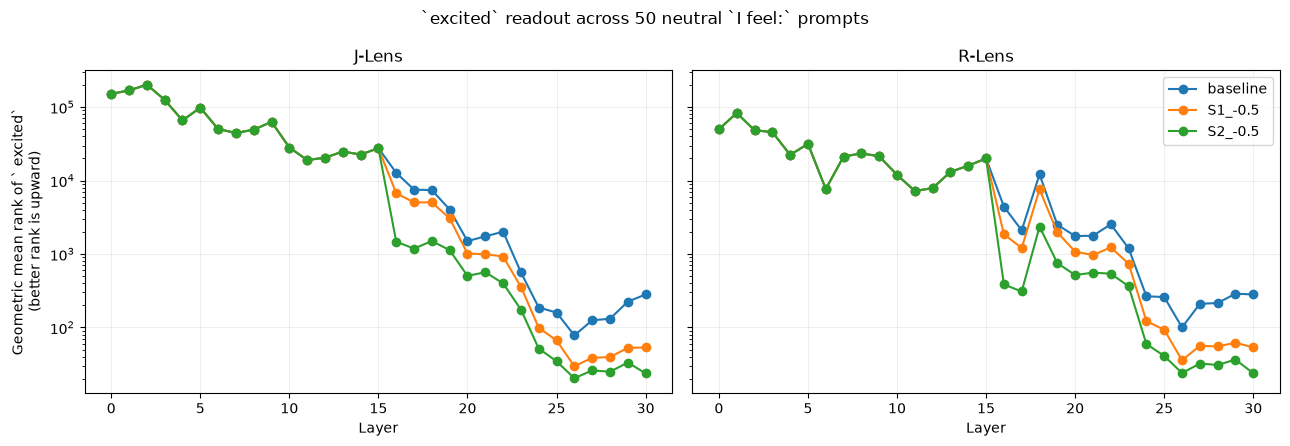

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5),
    sharey=True,
)

for ax, lens_name in zip(axes, ["J", "R"]):
    for condition in [
        "baseline",
        "S1_-0.5",
        "S2_-0.5",
    ]:
        sub = excited_summary[
            excited_summary["lens"].eq(lens_name)
            & excited_summary["condition"].eq(condition)
        ]

        ax.plot(
            sub["layer"],
            sub["geometric_mean_rank"],
            marker="o",
            label=condition,
        )

    ax.set_yscale("log")
    ax.invert_yaxis()
    ax.set_title(f"{lens_name}-Lens")
    ax.set_xlabel("Layer")
    ax.grid(alpha=0.2)

axes[0].set_ylabel(
    "Geometric mean rank of ` excited`\n"
    "(better rank is upward)"
)

axes[1].legend()

fig.suptitle(
    "`excited` readout across 50 neutral `I feel:` prompts"
)

fig.tight_layout()

fig.savefig(
    lens_dir / "excited_rank_trajectory.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

In [6]:
import unicodedata


def token_kind(token):
    s = token.strip()

    if not s:
        return "whitespace"

    if "_" in s and all(
        ch == "_"
        or ch.isspace()
        or unicodedata.category(ch).startswith("P")
        for ch in token
    ):
        return "blank_like"

    if any(ch.isalpha() for ch in s):
        return "word_like"

    if all(
        unicodedata.category(ch).startswith(("P", "S"))
        or ch.isspace()
        for ch in token
    ):
        return "punct_symbol"

    return "other"


lens_topk["token_kind"] = (
    lens_topk["token"].map(token_kind)
)

topk_composition = (
    lens_topk
    .groupby(
        [
            "condition",
            "lens",
            "layer",
            "token_kind",
        ]
    )
    .size()
    .rename("n")
    .reset_index()
)

totals = (
    topk_composition
    .groupby(
        ["condition", "lens", "layer"]
    )["n"]
    .transform("sum")
)

topk_composition["fraction"] = (
    topk_composition["n"] / totals
)

topk_composition.to_csv(
    lens_dir / "all50_topk_composition.csv",
    index=False,
)

display(
    topk_composition[
        topk_composition["condition"].eq("S2_-0.5")
        & topk_composition["layer"].isin(
            [8, 12, 16, 20, 24, 28, 30]
        )
    ].pivot_table(
        index=["layer", "lens"],
        columns="token_kind",
        values="fraction",
        fill_value=0,
    ).round(3)
)

token_kind  blank_like  other  punct_symbol  whitespace  word_like
layer lens                                                        
8     J          0.000  0.019         0.243       0.030      0.709
      R          0.023  0.000         0.250       0.000      0.727
12    J          0.013  0.005         0.148       0.017      0.817
      R          0.066  0.000         0.113       0.002      0.818
16    J          0.117  0.000         0.258       0.004      0.622
      R          0.198  0.000         0.140       0.001      0.662
20    J          0.468  0.000         0.307       0.123      0.102
      R          0.477  0.000         0.275       0.068      0.180
24    J          0.378  0.000         0.362       0.115      0.145
      R          0.384  0.000         0.315       0.097      0.204
28    J          0.661  0.000         0.060       0.006      0.273
      R          0.684  0.000         0.094       0.005      0.216
30    J          0.549  0.000         0.080       0.029      0.341
      R          0.549  0.000         0.080       0.029      0.341

In [7]:
cloud_scores = lens_topk.copy()

cloud_scores["rr"] = 1.0 / cloud_scores["rank"]

cloud_scores = (
    cloud_scores
    .groupby(
        [
            "condition",
            "lens",
            "layer",
            "token_id",
            "token",
            "token_kind",
        ],
        as_index=False,
    )
    .agg(
        cloud_weight=("rr", "sum"),
        prompt_count=("prompt_idx", "nunique"),
        mean_rank=("rank", "mean"),
    )
)

cloud_scores.to_csv(
    lens_dir / "all50_topk_cloud_scores.csv",
    index=False,
)


def show_cloud_table(
    condition,
    lens,
    layer,
    *,
    semantic_only=True,
    n=40,
):
    x = cloud_scores[
        cloud_scores["condition"].eq(condition)
        & cloud_scores["lens"].eq(lens)
        & cloud_scores["layer"].eq(layer)
    ]

    if semantic_only:
        x = x[x["token_kind"].eq("word_like")]

    return (
        x.sort_values(
            "cloud_weight",
            ascending=False,
        )
        .head(n)[
            [
                "token",
                "cloud_weight",
                "prompt_count",
                "mean_rank",
            ]
        ]
    )


print("S2 -0.5 / R-Lens / L12")
display(
    show_cloud_table(
        "S2_-0.5",
        "R",
        12,
    )
)

print("S2 -0.5 / R-Lens / L16")
display(
    show_cloud_table(
        "S2_-0.5",
        "R",
        16,
    )
)

print("S2 -0.5 / R-Lens / L20")
display(
    show_cloud_table(
        "S2_-0.5",
        "R",
        20,
    )
)

S2 -0.5 / R-Lens / L12


,token,cloud_weight,prompt_count,mean_rank
20701,feelings,35.194444,50,2.420000
20679,feeling,11.710629,49,7.530612
20697,emotional,8.282517,50,10.220000
20837,的情绪,8.227957,49,8.734694
20706,somehow,5.910446,49,12.469388
20821,怎样的,5.392452,48,13.770833
20818,情绪,5.353310,43,11.953488
20699,suddenly,4.929344,48,15.000000
20719,emotions,3.967776,45,15.600000
20790,sensations,3.933287,31,18.064516


S2 -0.5 / R-Lens / L16


,token,cloud_weight,prompt_count,mean_rank
21698,immediately,9.729136,49,8.163265
21724,feelings,9.506245,49,10.183673
21723,suddenly,4.318531,44,13.954545
21778,sensations,3.980239,34,17.970588
21811,这句话,3.757537,47,18.680851
21732,calm,2.925884,45,21.800000
21686,moment,2.306174,38,23.605263
21691,natural,2.228230,33,20.515152
21705,feeling,2.085241,38,22.710526
21797,瞬间,2.070370,35,21.371429


S2 -0.5 / R-Lens / L20


,token,cloud_weight,prompt_count,mean_rank
22493,feeling,2.098820,28,27.857143
22554,通则,1.088075,36,35.083333
22517,ế,1.002097,33,34.484848
22459,_A,0.922783,33,36.848485
22521,innen,0.533974,20,39.150000
22506,feelings,0.530840,18,36.333333
22440,os,0.488957,10,29.200000
22548,我的心,0.454552,20,44.700000
22509,calm,0.452967,10,33.600000
22557,松了一口气,0.440000,3,14.333333


In [8]:
# Compare top-k token-type composition across conditions.
#
# This tells us whether the late "blank / OPTIONS" transition is:
#   - generic to the neutral I-feel prompt,
#   - enhanced by either steering direction,
#   - or especially S2-specific.

kind_compare = (
    topk_composition[
        topk_composition["token_kind"].isin(
            ["word_like", "blank_like", "punct_symbol"]
        )
    ]
    .pivot_table(
        index=["layer", "lens", "condition"],
        columns="token_kind",
        values="fraction",
        fill_value=0,
    )
    .reset_index()
)

display(
    kind_compare[
        kind_compare["layer"].isin(
            [8, 12, 16, 18, 20, 24, 28, 30]
        )
    ].round(3)
)

token_kind,layer,lens,condition,blank_like,punct_symbol,word_like
48,8,J,S1_-0.5,0.000,0.243,0.709
49,8,J,S2_-0.5,0.000,0.243,0.709
50,8,J,baseline,0.000,0.243,0.709
51,8,R,S1_-0.5,0.023,0.250,0.727
52,8,R,S2_-0.5,0.023,0.250,0.727
53,8,R,baseline,0.023,0.250,0.727
72,12,J,S1_-0.5,0.013,0.148,0.817
73,12,J,S2_-0.5,0.013,0.148,0.817
74,12,J,baseline,0.013,0.148,0.817
75,12,R,S1_-0.5,0.066,0.113,0.818


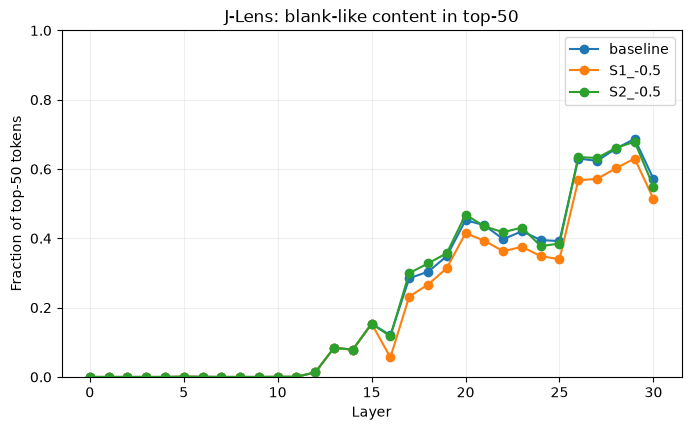

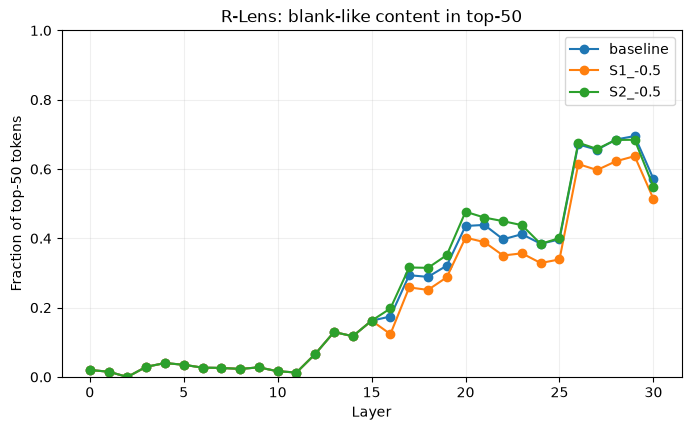

In [9]:
import matplotlib.pyplot as plt

for lens_name in ["J", "R"]:
    fig, ax = plt.subplots(figsize=(8, 4.5))

    for condition in [
        "baseline",
        "S1_-0.5",
        "S2_-0.5",
    ]:
        sub = kind_compare[
            kind_compare["lens"].eq(lens_name)
            & kind_compare["condition"].eq(condition)
        ]

        ax.plot(
            sub["layer"],
            sub["blank_like"],
            marker="o",
            label=condition,
        )

    ax.set_title(
        f"{lens_name}-Lens: blank-like content in top-50"
    )
    ax.set_xlabel("Layer")
    ax.set_ylabel("Fraction of top-50 tokens")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(alpha=0.2)

    plt.show()

In [10]:
# Difference from baseline in top-k composition.

baseline_kind = (
    kind_compare[
        kind_compare["condition"].eq("baseline")
    ]
    .set_index(["layer", "lens"])
)

delta_rows = []

for condition in ["S1_-0.5", "S2_-0.5"]:
    sub = (
        kind_compare[
            kind_compare["condition"].eq(condition)
        ]
        .set_index(["layer", "lens"])
    )

    for idx, row in sub.iterrows():
        base = baseline_kind.loc[idx]

        delta_rows.append({
            "layer": idx[0],
            "lens": idx[1],
            "condition": condition,
            "delta_blank": row["blank_like"] - base["blank_like"],
            "delta_word": row["word_like"] - base["word_like"],
            "delta_punct": row["punct_symbol"] - base["punct_symbol"],
        })

kind_delta = pd.DataFrame(delta_rows)

display(
    kind_delta[
        kind_delta["layer"].isin([16, 18, 20, 22, 24, 26, 28, 30])
    ].round(3)
)

,layer,lens,condition,delta_blank,delta_word,delta_punct
32,16,J,S1_-0.5,-0.064,0.091,-0.019
33,16,R,S1_-0.5,-0.051,0.054,0.001
36,18,J,S1_-0.5,-0.037,0.038,0.008
37,18,R,S1_-0.5,-0.038,0.050,-0.002
40,20,J,S1_-0.5,-0.038,0.001,-0.034
41,20,R,S1_-0.5,-0.034,0.010,-0.019
44,22,J,S1_-0.5,-0.035,-0.008,-0.031
45,22,R,S1_-0.5,-0.047,0.022,-0.010
48,24,J,S1_-0.5,-0.046,-0.035,-0.010
49,24,R,S1_-0.5,-0.056,-0.045,0.015


In [11]:
kind_delta_full = []

for condition in ["S1_-0.5", "S2_-0.5"]:
    sub = (
        kind_compare[
            kind_compare["condition"].eq(condition)
        ]
        .set_index(["layer", "lens"])
    )

    for idx, row in sub.iterrows():
        base = baseline_kind.loc[idx]

        out = {
            "layer": idx[0],
            "lens": idx[1],
            "condition": condition,
        }

        for kind in [
            "blank_like",
            "word_like",
            "punct_symbol",
            "whitespace",
            "other",
        ]:
            out[f"delta_{kind}"] = (
                row.get(kind, 0.0) - base.get(kind, 0.0)
            )

        kind_delta_full.append(out)

kind_delta_full = pd.DataFrame(kind_delta_full)

display(
    kind_delta_full[
        kind_delta_full["layer"].isin(
            [16, 18, 20, 22, 24, 26, 28, 30]
        )
    ].round(3)
)

,layer,lens,condition,delta_blank_like,delta_word_like,delta_punct_symbol,delta_whitespace,delta_other
32,16,J,S1_-0.5,-0.064,0.091,-0.019,0.0,0.0
33,16,R,S1_-0.5,-0.051,0.054,0.001,0.0,0.0
36,18,J,S1_-0.5,-0.037,0.038,0.008,0.0,0.0
37,18,R,S1_-0.5,-0.038,0.050,-0.002,0.0,0.0
40,20,J,S1_-0.5,-0.038,0.001,-0.034,0.0,0.0
41,20,R,S1_-0.5,-0.034,0.010,-0.019,0.0,0.0
44,22,J,S1_-0.5,-0.035,-0.008,-0.031,0.0,0.0
45,22,R,S1_-0.5,-0.047,0.022,-0.010,0.0,0.0
48,24,J,S1_-0.5,-0.046,-0.035,-0.010,0.0,0.0
49,24,R,S1_-0.5,-0.056,-0.045,0.015,0.0,0.0


In [12]:
# Correct full token-kind comparison.
#
# Rebuild from topk_composition WITHOUT filtering categories first.

kind_compare_full = (
    topk_composition
    .pivot_table(
        index=["layer", "lens", "condition"],
        columns="token_kind",
        values="fraction",
        fill_value=0,
    )
    .reset_index()
)

expected_kinds = [
    "blank_like",
    "word_like",
    "punct_symbol",
    "whitespace",
    "other",
]

for kind in expected_kinds:
    if kind not in kind_compare_full.columns:
        kind_compare_full[kind] = 0.0


baseline_full = (
    kind_compare_full[
        kind_compare_full["condition"].eq("baseline")
    ]
    .set_index(["layer", "lens"])
)

delta_rows = []

for condition in ["S1_-0.5", "S2_-0.5"]:
    sub = (
        kind_compare_full[
            kind_compare_full["condition"].eq(condition)
        ]
        .set_index(["layer", "lens"])
    )

    for idx, row in sub.iterrows():
        base = baseline_full.loc[idx]

        out = {
            "layer": idx[0],
            "lens": idx[1],
            "condition": condition,
        }

        for kind in expected_kinds:
            out[f"delta_{kind}"] = (
                row[kind] - base[kind]
            )

        # Sanity: composition differences should sum to ~0.
        out["delta_sum"] = sum(
            out[f"delta_{kind}"]
            for kind in expected_kinds
        )

        delta_rows.append(out)

kind_delta_full = pd.DataFrame(delta_rows)

display(
    kind_delta_full[
        kind_delta_full["layer"].isin(
            [16, 18, 20, 22, 24, 26, 28, 30]
        )
    ].round(3)
)

print(
    "max |delta sum|:",
    kind_delta_full["delta_sum"].abs().max(),
)

,layer,lens,condition,delta_blank_like,delta_word_like,delta_punct_symbol,delta_whitespace,delta_other,delta_sum
32,16,J,S1_-0.5,-0.064,0.091,-0.019,-0.008,0.000,0.0
33,16,R,S1_-0.5,-0.051,0.054,0.001,-0.004,-0.000,-0.0
36,18,J,S1_-0.5,-0.037,0.038,0.008,-0.009,0.000,0.0
37,18,R,S1_-0.5,-0.038,0.050,-0.002,-0.010,-0.000,-0.0
40,20,J,S1_-0.5,-0.038,0.001,-0.034,0.072,-0.001,0.0
41,20,R,S1_-0.5,-0.034,0.010,-0.019,0.045,-0.003,0.0
44,22,J,S1_-0.5,-0.035,-0.008,-0.031,0.073,0.000,-0.0
45,22,R,S1_-0.5,-0.047,0.022,-0.010,0.034,0.000,0.0
48,24,J,S1_-0.5,-0.046,-0.035,-0.010,0.092,0.000,0.0
49,24,R,S1_-0.5,-0.056,-0.045,0.015,0.085,0.000,-0.0


max |delta sum|: 9.540979117872439e-17


In [13]:
# Coarser format-vs-word diagnostic.

format_compare = kind_compare_full.copy()

format_compare["slot_like"] = (
    format_compare["blank_like"]
    + format_compare["whitespace"]
)

format_compare["format_like"] = (
    format_compare["blank_like"]
    + format_compare["whitespace"]
    + format_compare["punct_symbol"]
)

baseline_format = (
    format_compare[
        format_compare["condition"].eq("baseline")
    ]
    .set_index(["layer", "lens"])
)

rows = []

for condition in ["S1_-0.5", "S2_-0.5"]:
    sub = (
        format_compare[
            format_compare["condition"].eq(condition)
        ]
        .set_index(["layer", "lens"])
    )

    for idx, row in sub.iterrows():
        base = baseline_format.loc[idx]

        rows.append({
            "layer": idx[0],
            "lens": idx[1],
            "condition": condition,
            "delta_slot_like":
                row["slot_like"] - base["slot_like"],
            "delta_format_like":
                row["format_like"] - base["format_like"],
            "delta_word_like":
                row["word_like"] - base["word_like"],
        })

format_delta = pd.DataFrame(rows)

display(
    format_delta[
        format_delta["layer"].isin(
            [16, 18, 20, 22, 24, 26, 28, 30]
        )
    ].round(3)
)

,layer,lens,condition,delta_slot_like,delta_format_like,delta_word_like
32,16,J,S1_-0.5,-0.072,-0.091,0.091
33,16,R,S1_-0.5,-0.055,-0.054,0.054
36,18,J,S1_-0.5,-0.046,-0.038,0.038
37,18,R,S1_-0.5,-0.048,-0.050,0.050
40,20,J,S1_-0.5,0.034,0.000,0.001
41,20,R,S1_-0.5,0.012,-0.008,0.010
44,22,J,S1_-0.5,0.038,0.007,-0.008
45,22,R,S1_-0.5,-0.012,-0.022,0.022
48,24,J,S1_-0.5,0.045,0.035,-0.035
49,24,R,S1_-0.5,0.029,0.044,-0.045


In [14]:
# Which top-50 tokens are enriched/depleted by steering relative to baseline?
#
# Score = mean reciprocal rank across all 50 prompts, with absence from
# top-50 contributing zero. This is deliberately a top-k descriptive measure,
# not a full-vocabulary logit comparison.

import pandas as pd

x = lens_topk.copy()
x["rr"] = 1.0 / x["rank"]

# Every token's reciprocal-rank contribution, summed over prompts.
rr = (
    x.groupby(
        ["condition", "lens", "layer", "token_id", "token"],
        as_index=False,
    )
    .agg(
        rr_sum=("rr", "sum"),
        prompt_count=("prompt_idx", "nunique"),
    )
)

# Normalize by 50 prompts so absence = zero contribution.
rr["mrr50"] = rr["rr_sum"] / 50.0

base = (
    rr[rr["condition"].eq("baseline")]
    [["lens", "layer", "token_id", "token", "mrr50", "prompt_count"]]
    .rename(columns={
        "mrr50": "baseline_mrr50",
        "prompt_count": "baseline_prompt_count",
    })
)

rows = []

for condition in ["S1_-0.5", "S2_-0.5"]:
    steered = (
        rr[rr["condition"].eq(condition)]
        [["lens", "layer", "token_id", "token", "mrr50", "prompt_count"]]
        .rename(columns={
            "mrr50": "steered_mrr50",
            "prompt_count": "steered_prompt_count",
        })
    )

    merged = base.merge(
        steered,
        on=["lens", "layer", "token_id", "token"],
        how="outer",
    ).fillna(0)

    merged["condition"] = condition
    merged["delta_mrr50"] = (
        merged["steered_mrr50"]
        - merged["baseline_mrr50"]
    )

    rows.append(merged)

token_enrichment = pd.concat(rows, ignore_index=True)

token_enrichment.to_csv(
    lens_dir / "all50_top50_token_enrichment.csv",
    index=False,
)


def enriched(condition, lens, layer, n=30):
    return (
        token_enrichment[
            token_enrichment["condition"].eq(condition)
            & token_enrichment["lens"].eq(lens)
            & token_enrichment["layer"].eq(layer)
        ]
        .sort_values("delta_mrr50", ascending=False)
        .head(n)[
            [
                "token",
                "delta_mrr50",
                "steered_prompt_count",
                "baseline_prompt_count",
            ]
        ]
    )


def depleted(condition, lens, layer, n=30):
    return (
        token_enrichment[
            token_enrichment["condition"].eq(condition)
            & token_enrichment["lens"].eq(lens)
            & token_enrichment["layer"].eq(layer)
        ]
        .sort_values("delta_mrr50")
        .head(n)[
            [
                "token",
                "delta_mrr50",
                "steered_prompt_count",
                "baseline_prompt_count",
            ]
        ]
    )


for layer in [16, 20, 22, 24, 28]:
    print("\n" + "=" * 72)
    print(f"S2 -0.5 / R / L{layer}: ENRICHED")
    display(enriched("S2_-0.5", "R", layer, 20))

    print(f"S2 -0.5 / R / L{layer}: DEPLETED")
    display(depleted("S2_-0.5", "R", layer, 20))


S2 -0.5 / R / L16: ENRICHED


,token,delta_mrr50,steered_prompt_count,baseline_prompt_count
24662,____,0.081800,50.0,50.0
24631,?,0.077462,50.0,50.0
24750,calm,0.053448,45.0,7.0
24693,___,0.051255,50.0,49.0
24702,immediately,0.039122,49.0,48.0
24692,natural,0.031324,33.0,17.0
24816,sensations,0.030560,34.0,29.0
24841,瞬间,0.024462,35.0,23.0
24822,_____,0.024397,41.0,29.0
24740,suddenly,0.023768,44.0,43.0


S2 -0.5 / R / L16: DEPLETED


,token,delta_mrr50,steered_prompt_count,baseline_prompt_count
24742,feelings,-0.196190,49.0,49.0
24628,:,-0.084811,50.0,50.0
24738,emotional,-0.053757,18.0,43.0
24848,怎样的,-0.037680,27.0,48.0
24666,something,-0.037526,18.0,42.0
24867,的情绪,-0.028391,22.0,34.0
24655,what,-0.027192,6.0,29.0
24831,psych,-0.024732,1.0,25.0
24858,这句话,-0.021503,47.0,48.0
24687,?:,-0.020416,49.0,50.0



S2 -0.5 / R / L20: ENRICHED


...

,token,delta_mrr50,steered_prompt_count,baseline_prompt_count
26550,__,-0.082000,49.0,49.0
26578,____,-0.046667,49.0,49.0
26633,feeling,-0.032197,6.0,32.0
26532,\n,-0.031512,21.0,43.0
26641,feels,-0.027526,2.0,20.0
26623,___,-0.027379,49.0,49.0
26717,_\,-0.026857,48.0,48.0
26784,副处长,-0.025642,15.0,44.0
26554,\n,-0.024751,22.0,33.0
26718,OPTIONS,-0.021776,9.0,33.0



S2 -0.5 / R / L28: ENRICHED


,token,delta_mrr50,steered_prompt_count,baseline_prompt_count
27842,__,0.150509,49.0,49.0
27913,excited,0.049872,42.0,3.0
27986,exc,0.032878,33.0,8.0
28051,_____,0.024382,49.0,48.0
27936,__.,0.020498,49.0,49.0
28099,松了一口气,0.019771,13.0,6.0
27836,?,0.015542,30.0,3.0
28010,__/,0.014501,42.0,24.0
28015,relieved,0.014089,36.0,23.0
27895,warm,0.012431,27.0,11.0


S2 -0.5 / R / L28: DEPLETED


,token,delta_mrr50,steered_prompt_count,baseline_prompt_count
27848,____,-0.082222,49.0,49.0
27890,___,-0.029462,49.0,49.0
27823,I,-0.020301,1.0,17.0
27972,____,-0.017643,49.0,48.0
27888,DATE,-0.017143,1.0,1.0
28020,__;,-0.016972,48.0,47.0
27872,train,-0.016667,1.0,1.0
27989,warmth,-0.015715,4.0,3.0
27905,blank,-0.014619,13.0,34.0
27896,feeling,-0.014487,2.0,27.0


In [15]:
# Paired full-vocabulary logit/rank deltas for every frozen psych probe.
#
# Uses lens_vocab_ranks:
# prompt_idx, condition, lens, layer, family, term, rank, logit

import numpy as np
import pandas as pd


def paired_probe_delta(a, b, label):
    """
    a - b, paired by prompt.
    Rank improvement is reported as log(rank_b / rank_a):
      positive => term ranks better under a.
    """
    keys = [
        "prompt_idx",
        "lens",
        "layer",
        "family",
        "term",
        "token_id",
    ]

    aa = (
        lens_vocab_ranks[
            lens_vocab_ranks["condition"].eq(a)
        ][keys + ["rank", "logit"]]
        .rename(columns={
            "rank": "rank_a",
            "logit": "logit_a",
        })
    )

    bb = (
        lens_vocab_ranks[
            lens_vocab_ranks["condition"].eq(b)
        ][keys + ["rank", "logit"]]
        .rename(columns={
            "rank": "rank_b",
            "logit": "logit_b",
        })
    )

    x = aa.merge(bb, on=keys, validate="one_to_one")

    x["logit_delta"] = x["logit_a"] - x["logit_b"]

    # Positive = improved rank under condition a.
    x["log_rank_gain"] = np.log(
        x["rank_b"] / x["rank_a"]
    )

    summary = (
        x.groupby(
            ["lens", "layer", "family", "term"],
            as_index=False,
        )
        .agg(
            mean_logit_delta=("logit_delta", "mean"),
            median_logit_delta=("logit_delta", "median"),
            mean_log_rank_gain=("log_rank_gain", "mean"),
            median_log_rank_gain=("log_rank_gain", "median"),
            improved_prompts=(
                "log_rank_gain",
                lambda z: int((z > 0).sum()),
            ),
        )
    )

    summary["comparison"] = label
    return summary


probe_deltas = pd.concat(
    [
        paired_probe_delta(
            "S2_-0.5",
            "baseline",
            "S2 - baseline",
        ),
        paired_probe_delta(
            "S1_-0.5",
            "baseline",
            "S1 - baseline",
        ),
        paired_probe_delta(
            "S2_-0.5",
            "S1_-0.5",
            "S2 - S1",
        ),
    ],
    ignore_index=True,
)

probe_deltas.to_csv(
    lens_dir / "all50_psych_probe_deltas.csv",
    index=False,
)

# First look: S2 vs S1, R-Lens, selected layers.
display(
    probe_deltas[
        probe_deltas["comparison"].eq("S2 - S1")
        & probe_deltas["lens"].eq("R")
        & probe_deltas["layer"].isin(
            [12, 16, 20, 22, 24, 28, 30]
        )
    ]
    .sort_values(
        ["layer", "mean_log_rank_gain"],
        ascending=[True, False],
    )
    [
        [
            "layer",
            "family",
            "term",
            "mean_log_rank_gain",
            "mean_logit_delta",
            "improved_prompts",
        ]
    ]
)

,layer,family,term,mean_log_rank_gain,mean_logit_delta,improved_prompts
10020,12,activated_vitality,animated,0.000000,0.000000,0
10021,12,activated_vitality,eager,0.000000,0.000000,0
10022,12,activated_vitality,energetic,0.000000,0.000000,0
10023,12,activated_vitality,enthusiastic,0.000000,0.000000,0
10024,12,activated_vitality,excited,0.000000,0.000000,0
...,...,...,...,...,...,...
11155,30,inhibition_defeat,withdrawn,-0.991239,-0.906777,0
11119,30,calm_positive,content,-1.012804,-0.833750,0
11140,30,distress_self_devaluation,rejected,-1.306461,-1.411039,0
11110,30,agency_assurance,empowered,-1.587428,-1.188359,0


In [16]:
# Compact "who actually moves?" view.

def show_probe_extremes(
    comparison="S2 - S1",
    lens="R",
    layers=(16, 20, 22, 24, 28, 30),
    n=12,
):
    x = probe_deltas[
        probe_deltas["comparison"].eq(comparison)
        & probe_deltas["lens"].eq(lens)
    ]

    for layer in layers:
        z = x[x["layer"].eq(layer)]

        print("\n" + "=" * 72)
        print(f"{comparison} / {lens} / L{layer}: strongest gains")

        display(
            z.nlargest(n, "mean_log_rank_gain")[
                [
                    "family",
                    "term",
                    "mean_log_rank_gain",
                    "mean_logit_delta",
                    "improved_prompts",
                ]
            ]
        )

        print(f"{comparison} / {lens} / L{layer}: strongest losses")

        display(
            z.nsmallest(n, "mean_log_rank_gain")[
                [
                    "family",
                    "term",
                    "mean_log_rank_gain",
                    "mean_logit_delta",
                    "improved_prompts",
                ]
            ]
        )


show_probe_extremes()


S2 - S1 / R / L16: strongest gains


,family,term,mean_log_rank_gain,mean_logit_delta,improved_prompts
10264,activated_vitality,excited,1.575300,0.981406,50
10282,calm_positive,safe,1.513951,1.048828,50
10319,relief_release,relieved,1.300150,0.914098,50
10318,relief_release,relief,1.007838,0.765864,50
10283,calm_positive,secure,0.586449,0.786327,50
10277,approach_drive,ready,0.564243,0.416758,50
10267,agency_assurance,assured,0.551480,0.795098,50
10294,distress_self_devaluation,despair,0.540866,0.769668,50
10311,inhibition_defeat,helpless,0.362080,0.417733,50
10316,relief_release,eased,0.323172,0.968066,50


S2 - S1 / R / L16: strongest losses


,family,term,mean_log_rank_gain,mean_logit_delta,improved_prompts
10279,calm_positive,content,-1.294497,-0.742188,0
10300,distress_self_devaluation,rejected,-1.058239,-0.984684,0
10284,calm_positive,serene,-0.781317,-0.501055,0
10293,distress_self_devaluation,ashamed,-0.730596,-1.002400,0
10280,calm_positive,peaceful,-0.653999,-0.494653,0
10260,activated_vitality,animated,-0.608725,-0.363438,0
10308,generic_positive,pleased,-0.509090,-0.395566,0
10296,distress_self_devaluation,guilty,-0.500602,-0.376836,0
10304,generic_positive,glad,-0.500277,-0.288750,0
10315,inhibition_defeat,withdrawn,-0.402466,-0.735211,0



S2 - S1 / R / L20: strongest gains


...

,family,term,mean_log_rank_gain,mean_logit_delta,improved_prompts
10990,agency_assurance,empowered,-1.239277,-0.939336,0
11020,distress_self_devaluation,rejected,-0.979868,-1.115309,0
10999,calm_positive,content,-0.976119,-0.548906,1
11013,distress_self_devaluation,ashamed,-0.852963,-0.652285,0
11016,distress_self_devaluation,guilty,-0.802420,-0.452969,1
11035,inhibition_defeat,withdrawn,-0.800836,-0.630967,0
10994,approach_drive,determined,-0.644346,-0.423906,2
10991,agency_assurance,powerful,-0.587747,-0.630681,0
11033,inhibition_defeat,powerless,-0.428129,-0.382012,0
11019,distress_self_devaluation,miserable,-0.349842,-0.378736,0



S2 - S1 / R / L30: strongest gains


,family,term,mean_log_rank_gain,mean_logit_delta,improved_prompts
11122,calm_positive,safe,1.395211,1.047344,48
11101,activated_vitality,eager,1.081245,0.813281,50
11123,calm_positive,secure,0.854138,0.653906,48
11104,activated_vitality,excited,0.811530,1.301562,49
11102,activated_vitality,energetic,0.789079,0.510938,49
11156,relief_release,eased,0.741246,0.525781,50
11103,activated_vitality,enthusiastic,0.539329,0.329375,49
11130,competence_success,proficient,0.539060,0.597031,49
11105,activated_vitality,lively,0.530947,0.439141,49
11158,relief_release,relief,0.516456,0.435000,43


S2 - S1 / R / L30: strongest losses


,family,term,mean_log_rank_gain,mean_logit_delta,improved_prompts
11133,distress_self_devaluation,ashamed,-1.593355,-1.188125,0
11110,agency_assurance,empowered,-1.587428,-1.188359,0
11140,distress_self_devaluation,rejected,-1.306461,-1.411039,0
11119,calm_positive,content,-1.012804,-0.833750,0
11155,inhibition_defeat,withdrawn,-0.991239,-0.906777,0
11136,distress_self_devaluation,guilty,-0.898809,-0.783750,0
11153,inhibition_defeat,powerless,-0.801669,-0.683359,0
11114,approach_drive,determined,-0.770251,-0.616953,1
11111,agency_assurance,powerful,-0.749209,-0.695195,0
11149,inhibition_defeat,defeated,-0.550269,-0.516172,1


In [17]:
display(
    probe_deltas[
        probe_deltas["comparison"].eq("S2 - S1")
        & probe_deltas["term"].eq("excited")
    ][
        [
            "lens",
            "layer",
            "mean_log_rank_gain",
            "mean_logit_delta",
            "improved_prompts",
        ]
    ]
)

,lens,layer,mean_log_rank_gain,mean_logit_delta,improved_prompts
7444,J,0,0.000000,0.000000,0
7504,J,1,0.000000,0.000000,0
7564,J,2,0.000000,0.000000,0
7624,J,3,0.000000,0.000000,0
7684,J,4,0.000000,0.000000,0
...,...,...,...,...,...
10864,R,26,0.401268,1.240000,47
10924,R,27,0.555145,1.138437,50
10984,R,28,0.583400,1.258125,48
11044,R,29,0.524722,1.248125,49


In [19]:
# Family-level trajectories from the frozen psych vocabulary.
#
# Unit of observation:
#   prompt -> mean across frozen terms in family
#
# Then aggregate across the 50 prompts.
#
# Positive log-rank gain means the first condition ranks the family better.

import numpy as np
import pandas as pd


def paired_raw(a, b, label):
    keys = [
        "prompt_idx",
        "lens",
        "layer",
        "family",
        "term",
        "token_id",
    ]

    aa = (
        lens_vocab_ranks[
            lens_vocab_ranks["condition"].eq(a)
        ][keys + ["rank", "logit"]]
        .rename(columns={
            "rank": "rank_a",
            "logit": "logit_a",
        })
    )

    bb = (
        lens_vocab_ranks[
            lens_vocab_ranks["condition"].eq(b)
        ][keys + ["rank", "logit"]]
        .rename(columns={
            "rank": "rank_b",
            "logit": "logit_b",
        })
    )

    x = aa.merge(bb, on=keys, validate="one_to_one")

    x["log_rank_gain"] = np.log(
        x["rank_b"] / x["rank_a"]
    )

    x["logit_delta"] = (
        x["logit_a"] - x["logit_b"]
    )

    x["comparison"] = label

    return x


raw_pairwise = pd.concat(
    [
        paired_raw(
            "S2_-0.5",
            "baseline",
            "S2 - baseline",
        ),
        paired_raw(
            "S1_-0.5",
            "baseline",
            "S1 - baseline",
        ),
        paired_raw(
            "S2_-0.5",
            "S1_-0.5",
            "S2 - S1",
        ),
    ],
    ignore_index=True,
)


# First average terms within each family, separately for every prompt.
family_by_prompt = (
    raw_pairwise
    .groupby(
        [
            "comparison",
            "prompt_idx",
            "lens",
            "layer",
            "family",
        ],
        as_index=False,
    )
    .agg(
        mean_log_rank_gain=("log_rank_gain", "mean"),
        mean_logit_delta=("logit_delta", "mean"),
    )
)


# Then average across prompts.
family_summary = (
    family_by_prompt
    .groupby(
        [
            "comparison",
            "lens",
            "layer",
            "family",
        ],
        as_index=False,
    )
    .agg(
        mean_log_rank_gain=("mean_log_rank_gain", "mean"),
        median_log_rank_gain=("mean_log_rank_gain", "median"),
        mean_logit_delta=("mean_logit_delta", "mean"),
        median_logit_delta=("mean_logit_delta", "median"),
        positive_prompts=(
            "mean_log_rank_gain",
            lambda x: int((x > 0).sum()),
        ),
    )
)

family_by_prompt.to_csv(
    lens_dir / "all50_psych_family_by_prompt.csv",
    index=False,
)

family_summary.to_csv(
    lens_dir / "all50_psych_family_summary.csv",
    index=False,
)

In [20]:
display(
    family_summary[
        family_summary["comparison"].eq("S2 - S1")
        & family_summary["lens"].eq("R")
        & family_summary["layer"].isin(
            [16, 20, 22, 24, 28, 30]
        )
    ]
    .pivot_table(
        index="family",
        columns="layer",
        values="mean_log_rank_gain",
    )
    .round(2)
)

layer,16,20,22,24,28,30
family,,,,,,
activated_vitality,0.24,0.12,0.13,0.14,0.39,0.55
agency_assurance,0.00,-0.24,-0.15,-0.29,-0.25,-0.52
approach_drive,0.07,0.02,-0.06,-0.16,-0.18,-0.29
calm_positive,-0.07,-0.05,0.08,0.23,0.40,0.24
competence_success,0.09,0.06,0.02,0.02,0.02,0.09
distress_self_devaluation,-0.13,-0.26,-0.25,-0.25,-0.33,-0.57
generic_positive,-0.22,-0.44,-0.38,-0.26,-0.01,-0.10
inhibition_defeat,0.07,-0.14,-0.03,-0.12,-0.15,-0.39
relief_release,0.68,0.18,0.30,0.29,0.16,0.19


In [21]:
# Decompose the S2-vs-S1 family contrast:
# is S2 moving, S1 moving, or both?

layers_show = [16, 20, 22, 24, 28, 30]

family_threeway = (
    family_summary[
        family_summary["lens"].eq("R")
        & family_summary["layer"].isin(layers_show)
    ]
    .pivot_table(
        index=["family", "layer"],
        columns="comparison",
        values="mean_log_rank_gain",
    )
    .reset_index()
)

display(
    family_threeway.round(2)
)

comparison,family,layer,S1 - baseline,S2 - S1,S2 - baseline
0,activated_vitality,16,0.32,0.24,0.56
1,activated_vitality,20,0.07,0.12,0.19
2,activated_vitality,22,0.15,0.13,0.27
3,activated_vitality,24,0.12,0.14,0.26
4,activated_vitality,28,0.22,0.39,0.61
5,activated_vitality,30,0.36,0.55,0.91
6,agency_assurance,16,-0.13,0.00,-0.13
7,agency_assurance,20,-0.11,-0.24,-0.35
8,agency_assurance,22,0.00,-0.15,-0.15
9,agency_assurance,24,-0.01,-0.29,-0.30


In [22]:
for layer in [16, 24, 30]:
    print("\n", "=" * 68)
    print("LAYER", layer)

    display(
        family_threeway[
            family_threeway["layer"].eq(layer)
        ][
            [
                "family",
                "S2 - baseline",
                "S1 - baseline",
                "S2 - S1",
            ]
        ]
        .sort_values("S2 - S1", ascending=False)
        .round(2)
    )


LAYER 16


comparison,family,S2 - baseline,S1 - baseline,S2 - S1
48,relief_release,0.67,-0.01,0.68
0,activated_vitality,0.56,0.32,0.24
24,competence_success,-0.14,-0.23,0.09
12,approach_drive,-0.09,-0.16,0.07
42,inhibition_defeat,-0.57,-0.64,0.07
6,agency_assurance,-0.13,-0.13,0.00
18,calm_positive,1.08,1.15,-0.07
30,distress_self_devaluation,-1.23,-1.09,-0.13
36,generic_positive,0.61,0.83,-0.22



LAYER 24


comparison,family,S2 - baseline,S1 - baseline,S2 - S1
51,relief_release,0.72,0.43,0.29
21,calm_positive,0.43,0.20,0.23
3,activated_vitality,0.26,0.12,0.14
27,competence_success,-0.10,-0.12,0.02
45,inhibition_defeat,-0.61,-0.49,-0.12
15,approach_drive,-0.23,-0.07,-0.16
33,distress_self_devaluation,-0.66,-0.41,-0.25
39,generic_positive,0.70,0.95,-0.26
9,agency_assurance,-0.30,-0.01,-0.29



LAYER 30


comparison,family,S2 - baseline,S1 - baseline,S2 - S1
5,activated_vitality,0.91,0.36,0.55
23,calm_positive,0.48,0.24,0.24
53,relief_release,1.06,0.87,0.19
29,competence_success,-0.12,-0.22,0.09
41,generic_positive,1.19,1.29,-0.10
17,approach_drive,-0.15,0.14,-0.29
47,inhibition_defeat,-0.90,-0.51,-0.39
11,agency_assurance,-0.54,-0.03,-0.52
35,distress_self_devaluation,-1.23,-0.66,-0.57


In [23]:
# Leave-one-term-out family robustness for S2 - S1.
#
# For each family, remove each constituent term in turn and recompute
# the prompt-level family mean, then aggregate over prompts.

pair = raw_pairwise[
    raw_pairwise["comparison"].eq("S2 - S1")
].copy()

loto_rows = []

for family, fam_df in pair.groupby("family"):
    terms = sorted(fam_df["term"].unique())

    for omitted in terms:
        x = fam_df[
            ~fam_df["term"].eq(omitted)
        ]

        by_prompt = (
            x.groupby(
                ["prompt_idx", "lens", "layer"],
                as_index=False,
            )
            .agg(
                family_gain=("log_rank_gain", "mean"),
                family_logit=("logit_delta", "mean"),
            )
        )

        agg = (
            by_prompt.groupby(
                ["lens", "layer"],
                as_index=False,
            )
            .agg(
                mean_gain=("family_gain", "mean"),
                mean_logit=("family_logit", "mean"),
                positive_prompts=(
                    "family_gain",
                    lambda z: int((z > 0).sum()),
                ),
            )
        )

        agg["family"] = family
        agg["omitted_term"] = omitted
        loto_rows.append(agg)

family_loto = pd.concat(
    loto_rows,
    ignore_index=True,
)

family_loto.to_csv(
    lens_dir / "all50_family_leave_one_term_out.csv",
    index=False,
)

# Show worst-case leave-one-out result at selected layers.
loto_worst = (
    family_loto[
        family_loto["layer"].isin([16, 24, 28, 30])
    ]
    .groupby(
        ["family", "lens", "layer"],
        as_index=False,
    )
    .agg(
        worst_mean_gain=("mean_gain", "min"),
        best_mean_gain=("mean_gain", "max"),
    )
)

display(
    loto_worst[
        loto_worst["lens"].eq("R")
    ].pivot_table(
        index="family",
        columns="layer",
        values="worst_mean_gain",
    ).round(2)
)

layer,16,24,28,30
family,,,,
activated_vitality,0.01,0.04,0.28,0.46
agency_assurance,-0.13,-0.43,-0.40,-0.64
approach_drive,-0.03,-0.21,-0.25,-0.35
calm_positive,-0.33,0.02,0.10,0.05
competence_success,0.06,0.01,-0.05,0.03
distress_self_devaluation,-0.21,-0.30,-0.37,-0.62
generic_positive,-0.28,-0.29,-0.08,-0.20
inhibition_defeat,0.02,-0.17,-0.25,-0.50
relief_release,0.47,0.22,-0.03,0.01


In [24]:
display(
    loto_worst[
        loto_worst["lens"].eq("R")
        & loto_worst["layer"].isin([16, 24, 28, 30])
    ]
    .sort_values(["layer", "family"])
    .round(2)
)

,family,lens,layer,worst_mean_gain,best_mean_gain
4,activated_vitality,R,16,0.01,0.38
12,agency_assurance,R,16,-0.13,0.07
20,approach_drive,R,16,-0.03,0.12
28,calm_positive,R,16,-0.33,0.13
36,competence_success,R,16,0.06,0.11
44,distress_self_devaluation,R,16,-0.21,-0.03
52,generic_positive,R,16,-0.28,-0.17
60,inhibition_defeat,R,16,0.02,0.15
68,relief_release,R,16,0.47,0.88
5,activated_vitality,R,24,0.04,0.20


In [25]:
robust = loto_worst[
    loto_worst["lens"].eq("R")
].copy()

robust["robust_sign"] = np.select(
    [
        robust["worst_mean_gain"] > 0,
        robust["best_mean_gain"] < 0,
    ],
    [
        "positive",
        "negative",
    ],
    default="mixed",
)

display(
    robust[
        robust["layer"].isin([16, 24, 28, 30])
    ][
        [
            "family",
            "layer",
            "worst_mean_gain",
            "best_mean_gain",
            "robust_sign",
        ]
    ]
    .sort_values(["layer", "family"])
    .round(2)
)

,family,layer,worst_mean_gain,best_mean_gain,robust_sign
4,activated_vitality,16,0.01,0.38,positive
12,agency_assurance,16,-0.13,0.07,mixed
20,approach_drive,16,-0.03,0.12,mixed
28,calm_positive,16,-0.33,0.13,mixed
36,competence_success,16,0.06,0.11,positive
44,distress_self_devaluation,16,-0.21,-0.03,negative
52,generic_positive,16,-0.28,-0.17,negative
60,inhibition_defeat,16,0.02,0.15,positive
68,relief_release,16,0.47,0.88,positive
5,activated_vitality,24,0.04,0.20,positive


On Qwen3.5-4B, norm-matched S1 and S2 steering both produce broadly positive/anti-distress late readouts. Their internal profiles differ: S2 shows an early, leave-one-term-out-robust relief signal and a late, leave-one-term-out-robust activated-vitality advantage over S1. Generation is considerably narrower, with excited dominating the observed lexical difference.